# Examen Práctico — CC2017 Modelación y Simulación
## Grupo 1: Dinámica de Población Desplazada
### Ciudad UVG — Terremoto M6.8, 14 de noviembre, 4:00 AM

**Contexto:** Un terremoto de magnitud 6.8 sacudió Ciudad UVG (250,000 habitantes, 5 zonas urbanas),
causando daños estructurales diferenciados por zona, desplazamiento masivo de población y saturación
del sistema de albergues. El Comité de Emergencia asignó a este grupo la responsabilidad de modelar
la **dinámica de población desplazada y ocupación de albergues** durante las 72 horas posteriores al evento.

**Horizonte de simulación:** 72 horas, divididas en 12 bloques de 6 horas (T0 = 0-6h ... T11 = 66-72h).

**Fuente de datos:** `Grupo1_PoblacionDesplazada.xlsx` (datos sintéticos calibrados con parámetros
CEPREDENAC / OCHA Guatemala 2023).

**Dependencias del grupo (según enunciado del examen):**
- Recibe de **Grupo 6**: proyección de flujo real de desplazados por zona y momento (post-intercambio).
- Entrega a **Grupo 2** y **Grupo 3**: demanda de atención médica y demanda de suministros por zona/bloque,
  y el mapa de saturación de albergues.

Este notebook se construye en 26 secciones, siguiendo la estructura exigida para el examen: desde la
inspección completa del Excel hasta las conclusiones, limitaciones y la sección preparada (pero no
ejecutada) para el intercambio con Grupo 6.


## 2. Objetivos y preguntas del Grupo 1

El modelo debe responder las siguientes preguntas (enunciado del examen + guía de construcción):

1. ¿Qué zona supera primero el 80% de su capacidad operativa?
2. ¿En qué bloque y hora ocurre?
3. ¿Cuántas personas no encuentran alojamiento?
4. ¿Qué ocurre con esas personas en los bloques posteriores?
5. ¿Cuál es la demanda de atención médica por zona y bloque (entrega a Grupo 2)?
6. ¿Cuál es la demanda de suministros por zona y bloque (entrega a Grupo 3)?
7. Tras el intercambio con Grupo 6: ¿cuánto cambia el momento de saturación/colapso? *(sección preparada, pendiente de datos formales de Grupo 6)*
8. ¿Qué supuesto del modelo inicial resultó incorrecto o fue modificado tras el intercambio? *(pendiente de datos formales de Grupo 6)*

Adicionalmente, el examen exige responder específicamente:

- **Pregunta 1 (análisis propio):** zona y bloque donde el sistema de albergues supera 80% por primera vez;
  qué ocurre con quienes no encuentran lugar y cómo afecta esto a los bloques siguientes.
- **Pregunta 2 (integración del intercambio):** comparación de la proyección real de Grupo 6 contra la
  estimación propia; diferencia en horas del momento de colapso; supuesto inicial corregido.


## 3. Justificación del paradigma: System Dynamics (SD)

Este componente del sistema se modela con **System Dynamics (SD)** como paradigma principal, por las
siguientes razones formales:

- **Nivel de agregación de la pregunta:** interesa saber *cuántas personas* están alojadas, sin alojamiento,
  y qué demanda agregada (médica, suministros) generan por zona y bloque de tiempo — no el comportamiento
  o la ruta de cada individuo. Estas son **cantidades agregadas**, propias de SD.
- **Stocks y flujos naturales:** las personas alojadas (`A_z`) y sin alojamiento (`U_z`) son **acumulaciones
  (stocks)** que cambian por **flujos** de entrada (nuevos desplazados) y de transición (admisión a
  albergue, no atención). Esta es exactamente la estructura que SD representa mejor.
- **Dinámica temporal continua/agregada:** la evolución a lo largo de 12 bloques de 6 horas es central a
  la pregunta — no un resultado estático — y SD está diseñado para capturar trayectorias de stocks en el tiempo.
- **No se requiere identificación individual:** no es necesario simular a cada persona desplazada
  individualmente para responder las preguntas del grupo (a diferencia de, por ejemplo, decisiones de
  evacuación individuales, que corresponden al Grupo 6).
- **Heterogeneidad entre zonas:** se modelan las 5 zonas (Z1–Z5) de forma separada y explícita — cada una
  con su propia serie de desplazados, su propia capacidad operativa de albergues y su propia trayectoria de
  ocupación — para representar la heterogeneidad exigida por el examen. No se trata a las zonas como
  equivalentes.

**¿Por qué no SIR?** SIR modela transiciones epidemiológicas Susceptible→Infectado→Recuperado, que suponen
un mecanismo de "contagio" entre estados de una población homogénea. Aquí no existe un mecanismo de
contagio persona-a-persona: el paso de "sin alojamiento" a "alojado" depende de la **capacidad disponible
de albergues**, no de una tasa de transmisión entre individuos. Forzar una analogía S→I→R sería artificial
y no aportaría mayor poder explicativo que los stocks y flujos de SD ya definidos.

**¿Por qué no ABM?** El comportamiento individual de la población (a qué albergue ir, si autoevacuar,
si seguir instrucciones oficiales, efectos de desinformación/contagio social) es precisamente el objeto de
estudio del **Grupo 6** (Comportamiento de la Población y Toma de Decisiones). El Grupo 1 **recibe como
input** el flujo agregado resultante de ese comportamiento (columna "Desplazados acumulados buscando
albergue" del Excel, y en el futuro, el output formal de Grupo 6). Modelar ABM aquí duplicaría el trabajo
de Grupo 6 sin necesidad, y el examen explícitamente indica que Grupo 1 usa el output de Grupo 6 como
input, no que deba reconstruirlo.

No se agregan paradigmas adicionales (por ejemplo DES) porque no hay colas discretas de eventos individuales
que sea necesario resolver para responder las preguntas de este grupo — todo el problema es representable
como acumulación y flujo agregado por zona y bloque de tiempo.


## 4. Inspección completa del Excel

Antes de programar el modelo, se inspecciona íntegramente `Grupo1_PoblacionDesplazada.xlsx` para
identificar hojas, columnas, unidades, capacidades y el output exacto requerido. El archivo contiene
**una sola hoja** (`Datos_Grupo1`), organizada en 5 bloques:

1. Población por zona (estado previo al evento).
2. Daño estructural y desplazamiento inicial (T0, primeras 6h).
3. Evolución de desplazados en el tiempo (acumulados buscando albergue, T0–T11).
4. Capacidad de albergues disponibles (por albergue individual, con su zona asociada).
5. Output requerido — especificación textual de lo que este grupo debe entregar al intercambio.

Se imprime el contenido crudo de cada bloque para dejar constancia de los datos reales utilizados
(ningún valor fue inventado).


In [1]:
import openpyxl
from pathlib import Path

DATA_DIR = Path("../data").resolve() if Path("../data").exists() else Path("data").resolve()
EXCEL_PATH = DATA_DIR / "Grupo1_PoblacionDesplazada.xlsx"
OUTPUTS_DIR = Path("../outputs").resolve() if Path("../outputs").exists() else Path("outputs").resolve()
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

wb = openpyxl.load_workbook(str(EXCEL_PATH), data_only=True)
print("Hojas disponibles:", wb.sheetnames)
ws = wb["Datos_Grupo1"]
print("Dimensiones de la hoja:", ws.dimensions)

print("\n--- Contenido crudo completo (fila a fila) ---")
for row in ws.iter_rows(min_row=1, max_row=ws.max_row):
    valores = [c.value for c in row if c.value is not None]
    if valores:
        print(row[0].row, valores)


Hojas disponibles: ['Datos_Grupo1']
Dimensiones de la hoja: A1:M43

--- Contenido crudo completo (fila a fila) ---
1 ['EXAMEN PRÁCTICO — SEMANA 10 | Ciudad UVG — Terremoto M6.8']
2 ['GRUPO 1: Dinámica de Población Desplazada']
3 ['Fuente: datos sintéticos calibrados con parámetros CEPREDENAC / OCHA Guatemala 2023. Horizonte: 72h post-evento.']
5 ['1. POBLACIÓN POR ZONA — Estado previo al evento']
6 ['Zona', 'Población total', '% Vivienda precaria', 'Densidad (hab/km²)', 'Índice vulnerabilidad (0-1)']
7 ['Z1 (Centro histórico)', 48200, 0.22, 8400, 0.71]
8 ['Z2 (Norte residencial)', 61500, 0.11, 4200, 0.38]
9 ['Z3 (Sur industrial)', 35800, 0.31, 3100, 0.62]
10 ['Z4 (Este comercial)', 57300, 0.09, 5600, 0.29]
11 ['Z5 (Oeste periférico)', 47200, 0.41, 2800, 0.78]
13 ['2. DAÑO ESTRUCTURAL Y DESPLAZAMIENTO INICIAL (T0 — primeras 6 horas)']
14 ['Zona', '% Viviendas destruidas', '% Viviendas dañadas', 'Desplazados estimados T0', 'Necesitan albergue urgente']
15 ['Z1 (Centro histórico)', 0.34, 

**Observaciones de la inspección:**

- El bloque 2 (T0) y la columna `T0 (0-6h)` del bloque 3 **coinciden exactamente** con
  `Necesitan albergue urgente` de la sección de daño estructural — confirma consistencia interna del
  archivo y define cómo se maneja T0 (ver Sección 4 de ecuaciones más abajo).
- El bloque 3 reporta desplazados **acumulados** ("personas acumuladas buscando albergue"), no
  incrementos por bloque — por lo tanto se debe derivar `N_z(t) = D_z(t) - D_z(t-1)` para obtener los
  nuevos desplazados de cada bloque (con `D_z(-1) = 0`).
- El bloque 4 lista **albergues individuales**, no una capacidad única por zona. Z1, Z2 y Z3 tienen un
  único albergue cada una; **Z4 y Z5 tienen dos albergues cada una**, por lo que la capacidad operativa
  de zona es la **suma** de sus albergues.
- El archivo **no incluye** desviaciones estándar, rangos, ni distribuciones de probabilidad para ningún
  parámetro — esto se documenta explícitamente en la Sección 17 (Incertidumbre), donde se declara el
  supuesto adicional necesario para ejecutar Monte Carlo.
- El archivo **no incluye** tasas de salida de albergue, retorno a vivienda, ni reubicación entre zonas —
  por lo tanto el modelo **no incluye** los flujos opcionales `Salidas_z` ni `Reubicados_z` (quedan en 0),
  conforme a la instrucción de no inventar flujos no respaldados por datos.
- La Sección 5 del Excel (output requerido) especifica **exactamente** las dos tasas a usar:
  demanda médica = **18%** de los desplazados, y demanda de suministros = **100%** de quienes están en
  albergue. Estas tasas se usan literalmente, sin modificación.


## 5. Mapeo "dato del Excel → función dentro del modelo"

| Dato del Excel | Ubicación | Variable del modelo | Uso |
|---|---|---|---|
| `Zona` (bloque 1) | A7:A11 | índice `zona` | Clave de heterogeneidad (Z1–Z5) |
| `Población total` (bloque 1) | B7:B11 | `poblacion_total_z` | Referencia contextual (no entra directo en las ecuaciones de stock) |
| `Necesitan albergue urgente` (bloque 2) | E15:E19 | `D_z(T0)` (verificación) | Debe coincidir con columna T0 del bloque 3 (consistencia) |
| `T0..T11` desplazados acumulados (bloque 3) | B23:M27 | `D_z(t)`, t=0..11 | Serie de **desplazados acumulados buscando albergue**; insumo para derivar `N_z(t)` |
| `Capacidad operativa inicial` por albergue (bloque 4) | D31:D37 | `CapOperativa_z` | Suma por zona → capacidad operativa total de la zona (constante en el escenario base) |
| `Zona` de cada albergue (bloque 4) | B31:B37 | mapeo albergue→zona | Permite agregar capacidad por zona |
| Regla textual "18% de los desplazados" (bloque 5a) | A41 | `tasa_medica = 0.18` | `DemandaMedica_z(t) = tasa_medica * D_z(t)` |
| Regla textual "100% de quienes están en albergue" (bloque 5b) | A42 | `tasa_suministros = 1.00` | `DemandaSuministros_z(t) = tasa_suministros * A_z(t)` |
| Regla textual "supera 80% de capacidad operativa" (bloque 5c) | A43 | `UMBRAL_SATURACION = 0.80` | Detección de primer cruce de saturación |

**Ambigüedades identificadas y cómo se resolvieron (documentado, no inventado silenciosamente):**

1. *¿La demanda médica se calcula sobre desplazados totales o sobre alojados?* El texto dice
   "el 18% de los desplazados requieren atención médica" (no dice "de los alojados"), por lo que se usa
   `D_z(t)` (el total de desplazados acumulados en ese bloque, estén o no alojados). Esto se declara
   explícitamente como la interpretación adoptada.
2. *¿La capacidad operativa cambia con el tiempo (reparaciones)?* El Excel solo entrega una
   "capacidad operativa inicial" única, sin cronograma de cambio. **Supuesto documentado:** se asume
   capacidad operativa **constante** durante las 72 horas del escenario base. Este supuesto es fácilmente
   modificable (parámetro `capacidad_por_bloque` en la Sección 12).
3. *¿Existen salidas de albergue o reubicación entre zonas?* No hay datos que las respalden → se
   modelan como 0 (parámetros presentes en el código pero con valor nulo, para dejar la estructura lista
   si en el futuro se recibe esa información).


## 6. Definición de stocks, flujos, auxiliares, parámetros, inputs y outputs

| Variable | Tipo | Unidades | Descripción | Fuente |
|---|---|---|---|---|
| `A_z(t)` | Stock | personas | Personas alojadas en albergues de la zona z al final del bloque t | Calculado |
| `U_z(t)` | Stock | personas | Personas desplazadas sin alojamiento acumuladas en la zona z al final del bloque t | Calculado |
| `D_z(t)` | Input | personas (acumuladas) | Desplazados acumulados buscando albergue, dato directo del Excel | Excel, bloque 3 |
| `N_z(t)` | Flow | personas/bloque | Nuevos desplazados que requieren alojamiento en el bloque t = `D_z(t) - D_z(t-1)` | Derivado del Excel |
| `Admision_z(t)` | Flow | personas/bloque | Personas admitidas en albergue durante el bloque t | Calculado |
| `NoAtendidos_z(t)` | Flow | personas/bloque | Personas que no consiguen espacio en el bloque t | Calculado |
| `Salidas_z(t)` | Flow (no usado) | personas/bloque | Salidas de albergue — sin respaldo en datos, fijado en 0 | Supuesto documentado |
| `Reubicados_z(t)` | Flow (no usado) | personas/bloque | Reubicación entre zonas — sin respaldo en datos, fijado en 0 | Supuesto documentado |
| `CapOperativa_z` | Parámetro | personas | Capacidad operativa total de la zona (suma de sus albergues) | Excel, bloque 4 |
| `tasa_medica` | Parámetro | proporción | 0.18 — proporción de desplazados que requieren atención médica | Excel, bloque 5a |
| `tasa_suministros` | Parámetro | proporción | 1.00 — proporción de alojados que requieren suministros | Excel, bloque 5b |
| `UMBRAL_SATURACION` | Parámetro | proporción | 0.80 — umbral de saturación operativa | Excel, bloque 5c |
| `CapacidadDisponible_z(t)` | Auxiliar | personas | Espacio libre en albergues de la zona al inicio del bloque t | Calculado |
| `Ocupacion_z(t)` | Auxiliar | proporción [0,1] | `A_z(t) / CapOperativa_z` | Calculado |
| `DemandaMedica_z(t)` | Output | personas/bloque | `tasa_medica * D_z(t)` — entrega a Grupo 2 | Calculado |
| `DemandaSuministros_z(t)` | Output | personas/bloque | `tasa_suministros * A_z(t)` — entrega a Grupo 3 | Calculado |
| `bloque`, `hora` | Índice temporal | bloque (0-11), horas | 12 bloques de 6 horas, horizonte de 72h | Excel, bloque 3 (encabezados) |


## 7. Ecuaciones y reglas

**Derivación de nuevos desplazados a partir de datos acumulados (bloque 3 del Excel):**

```
N_z(0)  = D_z(0)                     (T0: no hay periodo previo, D_z(-1) := 0)
N_z(t)  = D_z(t) - D_z(t-1)          para t = 1..11
```

**Capacidad disponible y admisión:**

```
CapDisponible_z(t) = CapOperativa_z - A_z(t-1)         (A_z(-1) := 0)
Admision_z(t)       = min(N_z(t), CapDisponible_z(t))
NoAtendidos_z(t)    = max(0, N_z(t) - CapDisponible_z(t))
```

**Actualización de stocks:**

```
A_z(t) = A_z(t-1) + Admision_z(t)              (Salidas_z = 0, no respaldado por datos)
U_z(t) = U_z(t-1) + NoAtendidos_z(t)           (Reubicados_z = 0, no respaldado por datos)
```

**Nota de diseño (documentada explícitamente):** la demanda de un bloque (`N_z(t)`) se calcula solo con
los *nuevos* desplazados de ese bloque, no se vuelve a sumar `U_z(t-1)` a la demanda porque no existe en
los datos un mecanismo de salida o liberación de capacidad — la capacidad operativa es constante y solo
disminuye conforme se admite gente. En consecuencia, una vez que `CapDisponible_z(t) = 0`, toda persona sin
alojamiento permanece sin alojamiento en los bloques siguientes (se acumula en `U_z`), lo cual es
justamente la pregunta 3-4 del examen ("¿qué ocurre con las personas que no encuentran lugar... en los
bloques siguientes?"). Si en el futuro se recibieran datos de salidas/reubicación, bastaría con dejar de
fijar `Salidas_z`/`Reubicados_z` en 0.

**Auxiliares:**

```
Ocupacion_z(t) = A_z(t) / CapOperativa_z
```

**Outputs (Sección 5 del Excel, tasas exactas, sin modificación):**

```
DemandaMedica_z(t)      = 0.18 * D_z(t)
DemandaSuministros_z(t) = 1.00 * A_z(t)
```


## 7.1. Modelado Estructural de Habitabilidad en Viviendas Dañadas vs. Desplazamiento

### Justificación Teórica y Planteamiento del Problema
En la gestión de emergencias post-desastre (normativas CONRED en Guatemala y estándares internacionales ATC-20 / FEMA P-154), existe una distinción crítica entre **viviendas destruidas ($)**, **viviendas dañadas ($)** y **viviendas intactas ($)**:
- Una vivienda destruida ($) expulsa forzosamente al 100% de sus ocupantes (desplazamiento inmediato).
- Si las viviendas dañadas ($) también desplazaran al 100% de sus ocupantes, la variable carecería de sentido físico diferenciado respecto a las destruidas.
- En la realidad urbana, una vivienda catalogada como 'dañada' en una zona con baja intensidad destructiva suele presentar únicamente daños leves o cosméticos (desprendimiento de repellos, fisuras superficiales, caída de muros perimetrales no estructurales), por lo que permanece **habitable y segura**, evitando que sus ocupantes saturen los albergues.
- Por el contrario, en una zona de impacto catastrófico (alto $), las viviendas 'dañadas' sufren daño estructural severo (falla cortante en columnas, asentamientos diferenciales), siendo **inhabitables**.

### Evaluación Matemática de la Hipótesis Inicial
Se propuso inicialmente la expresión:
131852h = \left\lfloor d \cdot \left(rac{1}{2} - rac{b/c}{b+c}ight) ightfloor131852

**Evaluación técnica de la fórmula preliminar:**
1. **Inconsistencia de signo y rango:** Cuando =0.33$ y =0.33$, $rac{b/c}{b+c} = rac{1}{0.66} pprox 1.515$. Al restarlo de /2$, el factor resulta en hBc1.015 < 0$, produciendo un número negativo absurdo de viviendas habitables.
2. **Límite superior asimétrico:** Aun en un escenario ideal de daño nulo ( 	o 0, c 	o 1$), el término converge a /2$, limitando artificialmente la habitabilidad al 50% como máximo, cuando en una zona intacta casi el 95% de los daños leves son habitables.
3. **Asíntotas dimensionales:** La división por  \le 1$ actúa como un multiplicador artificioso al tratarse de números adimensionales en 1$.

### Formulación Robusta Corregida (Ratio de Preservación Estructural)
Para modelar este fenómeno de forma matemáticamente consistente y físicamente plausible, definimos el **Ratio de Integridad / Preservación Estructural del Entorno** $ho_z$:
131852ho_z = rac{c_z}{b_z + c_z} \in [0, 1]131852
Donde:
- Si  = 0$ (cero destrucción), $ho_z = 1.0$ (preservación total de las viviendas no dañadas).
- Si  = 0$ (cero casas intactas), $ho_z = 0.0$ (destrucción generalizada).
- Si  = c_z$ (simetría), $ho_z = 0.50$.

Para incorporar la **aversión al riesgo y el sesgo conservador** ante réplicas sísmicas (tendencia leve a desocupar por precaución), aplicamos un exponente de severidad $\gamma = 1.2$:
131852f_{\text{hab}, z} = ho_z^\gamma = \left(rac{c_z}{b_z + c_z}ight)^{1.2}131852

De esta forma:
- **Viviendas dañadas habitables:**  = \lfloor f_{\text{hab}, z} \cdot d_z floor$ (población que permanece en su hogar).
- **Viviendas dañadas no habitables:** {\text{no-hab}, z} = d_z - h_z$ (población que genera desplazamiento temporal o definitivo).


In [2]:
import numpy as np
import pandas as pd

# --- MODELADO DE HABITABILIDAD DE VIVIENDAS DAÑADAS ---
zonas_hab = ["Z1", "Z2", "Z3", "Z4", "Z5"]
b_vec = np.array([0.34, 0.08, 0.21, 0.05, 0.44])  # Destruidas
d_vec = np.array([0.28, 0.19, 0.31, 0.14, 0.22])  # Dañadas
c_vec = 1.0 - b_vec - d_vec                        # Intactas

# Ratio de preservación estructural y fracción de habitabilidad
rho_vec = c_vec / (b_vec + c_vec)
gamma_exp = 1.2
f_hab_vec = rho_vec ** gamma_exp

df_habitabilidad = pd.DataFrame({
    "Zona": zonas_hab,
    "% Destruidas (b)": np.round(b_vec * 100, 1),
    "% Dañadas (d)": np.round(d_vec * 100, 1),
    "% Intactas (c)": np.round(c_vec * 100, 1),
    "Ratio Preservación (rho)": np.round(rho_vec, 3),
    "Fracción Habitable (f_hab)": np.round(f_hab_vec, 3),
    "% Dañadas Habitables": np.round(f_hab_vec * 100, 1),
    "% Dañadas No Habitables (Desplazan)": np.round((1 - f_hab_vec) * 100, 1)
}).set_index("Zona")

print("=== TABLA DE HABITABILIDAD Y PRESERVACIÓN ESTRUCTURAL ===")
print(df_habitabilidad.to_string())



=== TABLA DE HABITABILIDAD Y PRESERVACIÓN ESTRUCTURAL ===
      % Destruidas (b)  % Dañadas (d)  % Intactas (c)  Ratio Preservación (rho)  Fracción Habitable (f_hab)  % Dañadas Habitables  % Dañadas No Habitables (Desplazan)
Zona                                                                                                                                                                  
Z1                34.0           28.0            38.0                     0.528                       0.464                  46.4                                 53.6
Z2                 8.0           19.0            73.0                     0.901                       0.883                  88.3                                 11.7
Z3                21.0           31.0            48.0                     0.696                       0.647                  64.7                                 35.3
Z4                 5.0           14.0            81.0                     0.942                       0.931

## 8. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

RNG_SEED_GLOBAL = 42  # semilla reproducible por defecto para todo el notebook
np.random.seed(RNG_SEED_GLOBAL)

pd.set_option("display.precision", 2)


## 9. Carga de datos

Se cargan directamente los 4 bloques de datos numéricos del Excel a estructuras de Python, en el mismo
orden y con los mismos valores inspeccionados en la Sección 4 (ningún valor se modifica ni se completa
con supuestos en esta etapa).


In [4]:
ZONAS = ["Z1", "Z2", "Z3", "Z4", "Z5"]
NOMBRES_ZONA = {
    "Z1": "Z1 (Centro histórico)",
    "Z2": "Z2 (Norte residencial)",
    "Z3": "Z3 (Sur industrial)",
    "Z4": "Z4 (Este comercial)",
    "Z5": "Z5 (Oeste periférico)",
}

# --- Bloque 1: población previa al evento (contexto) ---
poblacion_previa = pd.DataFrame({
    "zona": ZONAS,
    "poblacion_total": [48200, 61500, 35800, 57300, 47200],
    "pct_vivienda_precaria": [0.22, 0.11, 0.31, 0.09, 0.41],
    "densidad_hab_km2": [8400, 4200, 3100, 5600, 2800],
    "indice_vulnerabilidad": [0.71, 0.38, 0.62, 0.29, 0.78],
}).set_index("zona")

# --- Bloque 2: daño estructural y desplazamiento T0 (usado como verificación cruzada) ---
danio_t0 = pd.DataFrame({
    "zona": ZONAS,
    "pct_viviendas_destruidas": [0.34, 0.08, 0.21, 0.05, 0.44],
    "pct_viviendas_danadas": [0.28, 0.19, 0.31, 0.14, 0.22],
    "desplazados_estimados_t0": [16390, 4920, 7520, 2870, 20770],
    "necesitan_albergue_urgente": [11470, 2460, 4510, 1150, 14540],
}).set_index("zona")

# --- Bloque 3: desplazados acumulados buscando albergue, T0..T11 (dato directo del Excel) ---
bloques = list(range(12))  # 0..11
horas_inicio = [b * 6 for b in bloques]  # 0,6,12,...,66

D_acumulado = pd.DataFrame({
    "Z1": [11470, 13200, 14100, 14800, 15200, 15400, 15500, 15520, 15530, 15530, 15530, 15530],
    "Z2": [2460, 3100, 3800, 4200, 4400, 4500, 4520, 4520, 4520, 4520, 4520, 4520],
    "Z3": [4510, 5800, 6400, 6900, 7100, 7200, 7210, 7210, 7210, 7210, 7210, 7210],
    "Z4": [1150, 1400, 1700, 1900, 2000, 2050, 2060, 2060, 2060, 2060, 2060, 2060],
    "Z5": [14540, 17200, 19100, 20400, 21000, 21300, 21400, 21430, 21440, 21440, 21440, 21440],
}, index=bloques)
D_acumulado.index.name = "bloque"

# Verificación cruzada: T0 de la serie acumulada debe coincidir con "necesitan_albergue_urgente"
assert (D_acumulado.loc[0].reindex(ZONAS).values == danio_t0["necesitan_albergue_urgente"].reindex(ZONAS).values).all(), \
    "Inconsistencia entre T0 de la serie acumulada y 'necesitan albergue urgente' del bloque 2."
print("Verificación T0 OK: la serie acumulada coincide con 'necesitan albergue urgente'.")

# --- Bloque 4: albergues individuales con su zona y capacidad operativa inicial ---
albergues = pd.DataFrame([
    {"albergue": "Estadio Municipal",      "zona": "Z4", "capacidad_maxima": 4500, "capacidad_operativa": 3800, "estado": "Bueno"},
    {"albergue": "Escuela Central Z1",     "zona": "Z1", "capacidad_maxima": 800,  "capacidad_operativa": 400,  "estado": "Dañado — capacidad reducida"},
    {"albergue": "Polideportivo Z2",       "zona": "Z2", "capacidad_maxima": 2200, "capacidad_operativa": 2200, "estado": "Bueno"},
    {"albergue": "Centro Comunal Z4",      "zona": "Z4", "capacidad_maxima": 1500, "capacidad_operativa": 1500, "estado": "Bueno"},
    {"albergue": "Parque Industrial Z3",   "zona": "Z3", "capacidad_maxima": 3000, "capacidad_operativa": 2400, "estado": "Parcialmente dañado"},
    {"albergue": "Iglesia San Rafael Z5",  "zona": "Z5", "capacidad_maxima": 600,  "capacidad_operativa": 600,  "estado": "Bueno"},
    {"albergue": "Centro Deportivo Z5",    "zona": "Z5", "capacidad_maxima": 1800, "capacidad_operativa": 900,  "estado": "Dañado — capacidad reducida"},
])

print(albergues)


Verificación T0 OK: la serie acumulada coincide con 'necesitan albergue urgente'.
                albergue zona  capacidad_maxima  capacidad_operativa  \
0      Estadio Municipal   Z4              4500                 3800   
1     Escuela Central Z1   Z1               800                  400   
2       Polideportivo Z2   Z2              2200                 2200   
3      Centro Comunal Z4   Z4              1500                 1500   
4   Parque Industrial Z3   Z3              3000                 2400   
5  Iglesia San Rafael Z5   Z5               600                  600   
6    Centro Deportivo Z5   Z5              1800                  900   

                        estado  
0                        Bueno  
1  Dañado — capacidad reducida  
2                        Bueno  
3                        Bueno  
4          Parcialmente dañado  
5                        Bueno  
6  Dañado — capacidad reducida  


## 10. Limpieza y preparación de datos

No hay valores faltantes ni inconsistencias adicionales que limpiar (se validó T0 arriba). El único
procesamiento necesario es **agregar la capacidad operativa por zona** (sumando los albergues de Z4 y
Z5, que tienen dos cada una).


In [5]:
cap_operativa_zona = albergues.groupby("zona")["capacidad_operativa"].sum().reindex(ZONAS)
cap_maxima_zona = albergues.groupby("zona")["capacidad_maxima"].sum().reindex(ZONAS)

print("Capacidad operativa total por zona (personas):")
print(cap_operativa_zona)

# Validación de inputs: no debe haber NaN ni capacidades <= 0
assert cap_operativa_zona.notna().all(), "Capacidad operativa con valores faltantes."
assert (cap_operativa_zona > 0).all(), "Capacidad operativa debe ser positiva en todas las zonas."
assert (D_acumulado.values >= 0).all(), "Desplazados acumulados no pueden ser negativos."
print("\nValidación de inputs: OK")


Capacidad operativa total por zona (personas):
zona
Z1     400
Z2    2200
Z3    2400
Z4    5300
Z5    1500
Name: capacidad_operativa, dtype: int64

Validación de inputs: OK


## 11. Preparación zona × bloque

Se deriva `N_z(t)` (nuevos desplazados por bloque) a partir de la serie acumulada `D_z(t)`, con
`D_z(-1) := 0` como condición inicial (documentado en la Sección 7).


In [6]:
N_nuevos = D_acumulado.diff()
N_nuevos.iloc[0] = D_acumulado.iloc[0]  # T0: D_z(-1) = 0, por lo tanto N_z(0) = D_z(0)
N_nuevos = N_nuevos.astype(int)

print("Nuevos desplazados por bloque (N_z(t)):")
print(N_nuevos)

# Validación: la suma de N_z(t) a lo largo del tiempo debe reconstruir D_z(t) (consistencia del derivado)
reconstruido = N_nuevos.cumsum()
assert np.allclose(reconstruido.values, D_acumulado.values), "La derivación de N_z(t) no reconstruye D_z(t)."
print("\nValidación de derivación N_z(t) -> reconstruye D_z(t): OK")


Nuevos desplazados por bloque (N_z(t)):
           Z1    Z2    Z3    Z4     Z5
bloque                                
0       11470  2460  4510  1150  14540
1        1730   640  1290   250   2660
2         900   700   600   300   1900
3         700   400   500   200   1300
4         400   200   200   100    600
5         200   100   100    50    300
6         100    20    10    10    100
7          20     0     0     0     30
8          10     0     0     0     10
9           0     0     0     0      0
10          0     0     0     0      0
11          0     0     0     0      0

Validación de derivación N_z(t) -> reconstruye D_z(t): OK


## 12. Función principal `simular()`

Se implementa una única función reusable que recorre los 12 bloques y las 5 zonas, aplicando las
ecuaciones de la Sección 7. La función no depende de variables globales: recibe todos los datos y
parámetros como argumentos, y puede recibir `flujo_desplazados` alternativo (por ejemplo, el que
entregue Grupo 6) sin necesidad de duplicar código — este es el mecanismo pedido en la Sección 15
(intercambio con Grupo 6): **la misma función `simular()` se usa antes y después del intercambio**,
solo cambia el input `flujo_desplazados`.


In [7]:
def simular(flujo_desplazados: pd.DataFrame,
            capacidad_operativa: pd.Series,
            zonas: list,
            tasa_medica: float = 0.18,
            tasa_suministros: float = 1.00,
            capacidad_por_bloque: pd.DataFrame | None = None,
            seed: int | None = None,
            ruido_pct: float = 0.0) -> dict:
    """Simula la dinámica de población desplazada y ocupación de albergues por zona.

    Implementa las ecuaciones de stock y flujo de la Sección 7:
        N_z(t)              = flujo_desplazados (ya en incrementos por bloque)
        CapDisponible_z(t)  = CapOperativa_z - A_z(t-1)
        Admision_z(t)       = min(N_z(t), CapDisponible_z(t))
        NoAtendidos_z(t)    = max(0, N_z(t) - CapDisponible_z(t))
        A_z(t)              = A_z(t-1) + Admision_z(t)
        U_z(t)              = U_z(t-1) + NoAtendidos_z(t)
        Ocupacion_z(t)      = A_z(t) / CapOperativa_z
        DemandaMedica_z(t)      = tasa_medica * D_z(t)        (D_z(t) = acumulado = cumsum de N_z)
        DemandaSuministros_z(t) = tasa_suministros * A_z(t)

    Parameters
    ----------
    flujo_desplazados : DataFrame (index=bloque, columns=zonas)
        Nuevos desplazados por bloque, N_z(t). Es el ÚNICO input que cambia entre el escenario base
        (derivado del Excel propio) y el escenario post-intercambio (entregado por Grupo 6).
    capacidad_operativa : Series (index=zonas)
        Capacidad operativa total por zona. Constante en el escenario base (supuesto documentado,
        Sección 5), salvo que se provea `capacidad_por_bloque`.
    zonas : list
        Lista ordenada de zonas a simular (heterogeneidad explícita).
    tasa_medica, tasa_suministros : float
        Tasas exactas tomadas del Excel (Sección 5 del archivo), sin modificación.
    capacidad_por_bloque : DataFrame opcional (index=bloque, columns=zonas)
        Si se provee, permite capacidad operativa variable en el tiempo (no usado en el escenario base
        por falta de datos, pero disponible para escenarios futuros con cronograma de reparación).
    seed : int opcional
        Semilla reproducible para el componente de incertidumbre (Sección 17).
    ruido_pct : float
        Desviación estándar relativa (multiplicativa) aplicada a N_z(t) para Monte Carlo. 0.0 = sin
        incertidumbre (corrida determinista). Ver Sección 17 para la justificación de este supuesto.

    Returns
    -------
    dict de DataFrames: 'alojados', 'no_alojados', 'ocupacion', 'admision', 'no_atendidos',
    'demanda_medica', 'demanda_suministros', 'nuevos_desplazados', 'acumulado_desplazados'
    """
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    bloques_sim = list(flujo_desplazados.index)
    n_bloques = len(bloques_sim)

    # Validación de inputs
    if not set(zonas).issubset(set(flujo_desplazados.columns)):
        raise ValueError("flujo_desplazados no contiene todas las zonas requeridas.")
    if not set(zonas).issubset(set(capacidad_operativa.index)):
        raise ValueError("capacidad_operativa no contiene todas las zonas requeridas.")

    alojados = pd.DataFrame(0.0, index=bloques_sim, columns=zonas)
    no_alojados = pd.DataFrame(0.0, index=bloques_sim, columns=zonas)
    ocupacion = pd.DataFrame(0.0, index=bloques_sim, columns=zonas)
    admision = pd.DataFrame(0.0, index=bloques_sim, columns=zonas)
    no_atendidos = pd.DataFrame(0.0, index=bloques_sim, columns=zonas)
    nuevos = pd.DataFrame(0.0, index=bloques_sim, columns=zonas)

    A_prev = {z: 0.0 for z in zonas}
    U_prev = {z: 0.0 for z in zonas}

    for t in bloques_sim:
        for z in zonas:
            cap_z = (capacidad_por_bloque.loc[t, z] if capacidad_por_bloque is not None
                     else capacidad_operativa[z])

            n_zt = flujo_desplazados.loc[t, z]
            if ruido_pct > 0:
                n_zt = max(0.0, n_zt * (1 + rng.normal(0, ruido_pct)))

            cap_disponible = max(0.0, cap_z - A_prev[z])
            adm = min(n_zt, cap_disponible)
            no_at = max(0.0, n_zt - cap_disponible)

            A_t = A_prev[z] + adm
            U_t = U_prev[z] + no_at

            nuevos.loc[t, z] = n_zt
            admision.loc[t, z] = adm
            no_atendidos.loc[t, z] = no_at
            alojados.loc[t, z] = A_t
            no_alojados.loc[t, z] = U_t
            ocupacion.loc[t, z] = A_t / cap_z

            A_prev[z] = A_t
            U_prev[z] = U_t

    acumulado_desplazados = nuevos.cumsum()
    demanda_medica = tasa_medica * acumulado_desplazados
    demanda_suministros = tasa_suministros * alojados

    return {
        "alojados": alojados,
        "no_alojados": no_alojados,
        "ocupacion": ocupacion,
        "admision": admision,
        "no_atendidos": no_atendidos,
        "nuevos_desplazados": nuevos,
        "acumulado_desplazados": acumulado_desplazados,
        "demanda_medica": demanda_medica,
        "demanda_suministros": demanda_suministros,
    }


## 13. Corrida base

Se ejecuta `simular()` de forma determinista (`ruido_pct=0`) con los datos derivados directamente del
Excel, para obtener la trayectoria base antes de cualquier incorporación de incertidumbre o del
intercambio con Grupo 6.


In [8]:
resultado_base = simular(
    flujo_desplazados=N_nuevos,
    capacidad_operativa=cap_operativa_zona,
    zonas=ZONAS,
    tasa_medica=0.18,
    tasa_suministros=1.00,
    seed=RNG_SEED_GLOBAL,
    ruido_pct=0.0,
)

print("Ocupación por zona y bloque (escenario base, determinista):")
print(resultado_base["ocupacion"].round(3))


Ocupación por zona y bloque (escenario base, determinista):
     Z1   Z2   Z3    Z4   Z5
0   1.0  1.0  1.0  0.22  1.0
1   1.0  1.0  1.0  0.26  1.0
2   1.0  1.0  1.0  0.32  1.0
3   1.0  1.0  1.0  0.36  1.0
4   1.0  1.0  1.0  0.38  1.0
5   1.0  1.0  1.0  0.39  1.0
6   1.0  1.0  1.0  0.39  1.0
7   1.0  1.0  1.0  0.39  1.0
8   1.0  1.0  1.0  0.39  1.0
9   1.0  1.0  1.0  0.39  1.0
10  1.0  1.0  1.0  0.39  1.0
11  1.0  1.0  1.0  0.39  1.0


## 14. Verificación automática

**Verificación** = comprobar que el código implementa correctamente el modelo diseñado (chequeos
internos de consistencia matemática). **Validación** = comprobar que el modelo representa
adecuadamente el sistema real (esto último requeriría comparar contra datos observados reales del
terremoto, que están fuera del alcance de este examen — se deja como limitación en la Sección 26).

Se implementan las siguientes comprobaciones automáticas de verificación:


In [9]:
def verificar_resultado(resultado: dict, capacidad_operativa: pd.Series, zonas: list) -> None:
    """Ejecuta comprobaciones automáticas de verificación sobre el resultado de simular().

    Lanza AssertionError con un mensaje descriptivo si alguna comprobación falla.
    """
    alojados = resultado["alojados"]
    no_alojados = resultado["no_alojados"]
    ocupacion = resultado["ocupacion"]

    # 1. Stocks >= 0
    assert (alojados.values >= -1e-9).all(), "Se encontraron valores negativos en 'alojados'."
    assert (no_alojados.values >= -1e-9).all(), "Se encontraron valores negativos en 'no_alojados'."

    # 2. Alojados <= capacidad operativa de su zona
    for z in zonas:
        assert (alojados[z].values <= capacidad_operativa[z] + 1e-6).all(), \
            f"Zona {z}: alojados excede la capacidad operativa."

    # 3. 0 <= ocupacion <= 1
    assert (ocupacion.values >= -1e-9).all() and (ocupacion.values <= 1 + 1e-6).all(), \
        "Ocupación fuera del rango [0, 1]."

    # 4. Ausencia de NaN inesperados
    for nombre, df in resultado.items():
        assert not df.isna().any().any(), f"Se encontraron NaN en '{nombre}'."

    # 5. Dimensiones correctas zona x tiempo
    n_bloques_esperado = 12
    for nombre, df in resultado.items():
        assert df.shape == (n_bloques_esperado, len(zonas)), \
            f"'{nombre}' tiene dimensiones {df.shape}, se esperaba ({n_bloques_esperado}, {len(zonas)})."

    print("Todas las verificaciones automáticas pasaron correctamente.")


verificar_resultado(resultado_base, cap_operativa_zona, ZONAS)


Todas las verificaciones automáticas pasaron correctamente.


## 15. Detección del primer cruce del 80% (saturación)

Se implementa la función que responde directamente la **Pregunta 1 de análisis propio** del examen:
en qué zona y bloque el sistema de albergues supera por primera vez el 80% de su capacidad operativa.


In [10]:
def detectar_saturacion(ocupacion: pd.DataFrame, umbral: float = 0.80) -> pd.DataFrame:
    """Encuentra, para cada zona, el primer bloque donde la ocupación supera `umbral`.

    Retorna una tabla Zona | Primer bloque >umbral | Hora | Ocupación observada.
    Si una zona nunca cruza el umbral, se indica explícitamente con NaN / 'Nunca'.
    """
    filas = []
    for z in ocupacion.columns:
        serie = ocupacion[z]
        cruces = serie[serie > umbral]
        if len(cruces) > 0:
            primer_bloque = cruces.index[0]
            hora = primer_bloque * 6
            filas.append({
                "Zona": z,
                f"Primer bloque >{int(umbral*100)}%": primer_bloque,
                "Hora (desde el evento)": f"{hora}h",
                "Ocupación observada": round(serie.loc[primer_bloque], 4),
            })
        else:
            filas.append({
                "Zona": z,
                f"Primer bloque >{int(umbral*100)}%": "Nunca",
                "Hora (desde el evento)": "Nunca",
                "Ocupación observada": round(serie.max(), 4),
            })
    tabla = pd.DataFrame(filas).set_index("Zona")
    return tabla


tabla_saturacion_base = detectar_saturacion(resultado_base["ocupacion"], umbral=0.80)
print(tabla_saturacion_base)

# Primera zona de TODO el sistema en cruzar el umbral (menor bloque; empate se rompe por menor hora exacta
# usando la ocupación en ese bloque como criterio secundario informativo)
cruces_validos = tabla_saturacion_base[tabla_saturacion_base.iloc[:, 0] != "Nunca"]
if len(cruces_validos) > 0:
    zona_primera = cruces_validos.iloc[:, 0].astype(int).idxmin()
    bloque_primero = cruces_validos.iloc[:, 0].astype(int).min()
    print(f"\n>>> Primera zona en saturarse (>80%): {zona_primera}, en el bloque {bloque_primero} "
          f"({bloque_primero*6}h - {(bloque_primero+1)*6}h post-evento).")
else:
    print("\n>>> Ninguna zona supera el 80% de su capacidad operativa en el escenario base.")


     Primer bloque >80% Hora (desde el evento)  Ocupación observada
Zona                                                               
Z1                    0                     0h                 1.00
Z2                    0                     0h                 1.00
Z3                    0                     0h                 1.00
Z4                Nunca                  Nunca                 0.39
Z5                    0                     0h                 1.00

>>> Primera zona en saturarse (>80%): Z1, en el bloque 0 (0h - 6h post-evento).


**Hallazgo clave (no decorativo):** la tabla anterior muestra que **cuatro de las cinco zonas
(Z1, Z2, Z3 y Z5) superan el 80% de su capacidad operativa desde el primer bloque (0-6h)**, es decir,
la demanda inicial de desplazados que requieren albergue ya excedía la capacidad operativa disponible
desde el momento del terremoto en esas zonas. Solo **Z4** nunca cruza el umbral (se estabiliza en ~39%
de ocupación). El desempate para "la primera zona en saturarse" se resuelve por el orden de la lista
`ZONAS` (Z1 antes que Z2/Z3/Z5) ya que las cuatro comparten el mismo bloque de saturación (bloque 0);
en la práctica, **el sistema de albergues colapsa simultáneamente en la gran mayoría de la ciudad desde
las primeras 6 horas**, no de forma escalonada. Esto es consistente con las capacidades operativas muy
bajas reportadas en el Excel (por ejemplo, Z1 solo cuenta con 400 cupos operativos frente a ~11,470
desplazados iniciales que necesitan albergue urgente).


## 16. Análisis de población sin alojamiento

Responde las preguntas 3 y 4 del examen: ¿cuántas personas no encuentran alojamiento, y qué ocurre con
ellas en los bloques posteriores? Dado que el modelo base no incluye salidas de albergue ni reubicación
(sin respaldo de datos), la población sin alojamiento (`U_z`) es **monótonamente no decreciente**: una
vez que una zona se queda sin capacidad disponible, todo nuevo desplazado adicional pasa a acumularse en
`U_z` y **permanece ahí** durante el resto del horizonte de 72 horas.


In [11]:
no_alojados_base = resultado_base["no_alojados"]

print("Personas sin alojamiento acumuladas por zona y bloque (escenario base):")
print(no_alojados_base.astype(int))

print("\nMáximo de personas sin alojamiento por zona (al final del horizonte, bloque 11 = hora 72):")
print(no_alojados_base.iloc[-1].astype(int).sort_values(ascending=False))

total_sin_alojamiento_final = no_alojados_base.iloc[-1].sum()
print(f"\nTotal de personas sin alojamiento en todo el sistema al final de las 72h: "
      f"{int(total_sin_alojamiento_final)} personas.")

# ¿En qué bloque aparece la primera persona sin alojamiento, por zona?
primer_no_atendido = {}
for z in ZONAS:
    serie = no_alojados_base[z]
    bloques_con_no_atendidos = serie[serie > 0]
    primer_no_atendido[z] = bloques_con_no_atendidos.index[0] if len(bloques_con_no_atendidos) > 0 else "Nunca"
print("\nPrimer bloque con personas sin alojamiento, por zona:")
print(pd.Series(primer_no_atendido))


Personas sin alojamiento acumuladas por zona y bloque (escenario base):
       Z1    Z2    Z3  Z4     Z5
0   11070   260  2110   0  13040
1   12800   900  3400   0  15700
2   13700  1600  4000   0  17600
3   14400  2000  4500   0  18900
4   14800  2200  4700   0  19500
5   15000  2300  4800   0  19800
6   15100  2320  4810   0  19900
7   15120  2320  4810   0  19930
8   15130  2320  4810   0  19940
9   15130  2320  4810   0  19940
10  15130  2320  4810   0  19940
11  15130  2320  4810   0  19940

Máximo de personas sin alojamiento por zona (al final del horizonte, bloque 11 = hora 72):
Z5    19940
Z1    15130
Z3     4810
Z2     2320
Z4        0
Name: 11, dtype: int64

Total de personas sin alojamiento en todo el sistema al final de las 72h: 42200 personas.

Primer bloque con personas sin alojamiento, por zona:
Z1        0
Z2        0
Z3        0
Z4    Nunca
Z5        0
dtype: object


## 17. Incertidumbre / múltiples realizaciones

**Inspección del Excel respecto a incertidumbre:** el archivo `Grupo1_PoblacionDesplazada.xlsx` **no
proporciona** desviaciones estándar, rangos, intervalos ni ninguna distribución de probabilidad para
ninguno de sus parámetros (población, desplazados, capacidades). Todos los valores son puntuales.

Por lo tanto, conforme a la instrucción de no inventar silenciosamente desviaciones estándar o
distribuciones, se declara aquí de forma explícita el **supuesto adicional necesario** para poder
ejecutar un análisis Monte Carlo con al menos 30 realizaciones (requisito del examen):

> **Supuesto de incertidumbre (declarado, no respaldado por datos del Excel):** el número de nuevos
> desplazados `N_z(t)` que llegan en cada bloque tiene una variabilidad multiplicativa aleatoria
> `N_z(t) * (1 + e)`, con `e ~ Normal(0, ruido_pct)`. El valor por defecto usado aquí es
> `ruido_pct = 0.10` (10%), elegido únicamente como punto de partida razonable para ilustrar el método,
> **no como un dato del Excel**. Este parámetro es fácilmente modificable (variable `RUIDO_PCT` en la
> siguiente celda) y su valor debería ser sustituido por un rango real (por ejemplo, provisto por
> Grupo 6, que sí modela el comportamiento poblacional) tan pronto se disponga de esa información.

Se ejecutan 100 realizaciones (por encima del mínimo de 30 exigido) con semillas reproducibles
(`seed = i` para la realización `i`), variando únicamente `N_z(t)` según el supuesto anterior; el resto
de las ecuaciones y capacidades permanecen fijas.


In [12]:
RUIDO_PCT = 0.10  # Supuesto declarado en la celda anterior — NO proviene del Excel. Fácilmente modificable.
N_REALIZACIONES = 100  # >= 30 exigido por el examen

def correr_monte_carlo(flujo_desplazados, capacidad_operativa, zonas,
                        n_realizaciones=100, ruido_pct=0.10, seed_base=0):
    """Ejecuta `simular()` n_realizaciones veces con ruido multiplicativo reproducible sobre N_z(t).

    Retorna un dict de listas de DataFrames (una por realización) para cada variable de interés.
    """
    claves = ["alojados", "no_alojados", "ocupacion", "demanda_medica", "demanda_suministros"]
    trayectorias = {k: [] for k in claves}

    for i in range(n_realizaciones):
        res_i = simular(
            flujo_desplazados=flujo_desplazados,
            capacidad_operativa=capacidad_operativa,
            zonas=zonas,
            tasa_medica=0.18,
            tasa_suministros=1.00,
            seed=seed_base + i,
            ruido_pct=ruido_pct,
        )
        for k in claves:
            trayectorias[k].append(res_i[k])

    return trayectorias


trayectorias_mc = correr_monte_carlo(
    N_nuevos, cap_operativa_zona, ZONAS,
    n_realizaciones=N_REALIZACIONES, ruido_pct=RUIDO_PCT, seed_base=RNG_SEED_GLOBAL,
)

print(f"Monte Carlo ejecutado: {N_REALIZACIONES} realizaciones, ruido_pct={RUIDO_PCT} (supuesto declarado).")

# Momento de saturación (>80%) por realización, para la métrica de incertidumbre de la Sección 18
bloques_saturacion_mc = {z: [] for z in ZONAS}
for ocup_i in trayectorias_mc["ocupacion"]:
    tabla_i = detectar_saturacion(ocup_i, umbral=0.80)
    for z in ZONAS:
        val = tabla_i.loc[z].iloc[0]
        bloques_saturacion_mc[z].append(val if val != "Nunca" else np.nan)


Monte Carlo ejecutado: 100 realizaciones, ruido_pct=0.1 (supuesto declarado).


## 18. Media e intervalo de confianza 95% (Bootstrap)

Se reporta media e IC95% (percentiles 2.5 y 97.5, vía bootstrap con remuestreo con reemplazo sobre las
100 realizaciones Monte Carlo) para las métricas principales exigidas por el examen: ocupación,
población sin alojamiento, demanda médica, demanda de suministros, y momento de saturación.


In [13]:
def bootstrap_ic95(muestras: np.ndarray, n_bootstrap: int = 2000, seed: int = RNG_SEED_GLOBAL):
    """Calcula media e IC95% vía bootstrap (remuestreo con reemplazo, percentiles 2.5/97.5)."""
    rng = np.random.default_rng(seed)
    muestras = muestras[~np.isnan(muestras)]
    if len(muestras) == 0:
        return np.nan, np.nan, np.nan
    medias_bootstrap = np.array([
        rng.choice(muestras, size=len(muestras), replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    return muestras.mean(), np.percentile(medias_bootstrap, 2.5), np.percentile(medias_bootstrap, 97.5)


def resumen_ic95_por_zona_bloque(lista_trayectorias: list, zonas: list, bloques: list) -> tuple:
    """Para una métrica (lista de DataFrames zona x bloque, una por realización), calcula
    media e IC95% (bootstrap) por zona y bloque. Retorna (df_media, df_ic_low, df_ic_high)."""
    media = pd.DataFrame(index=bloques, columns=zonas, dtype=float)
    ic_low = pd.DataFrame(index=bloques, columns=zonas, dtype=float)
    ic_high = pd.DataFrame(index=bloques, columns=zonas, dtype=float)
    for z in zonas:
        for t in bloques:
            valores = np.array([df.loc[t, z] for df in lista_trayectorias])
            m, lo, hi = bootstrap_ic95(valores, n_bootstrap=500)  # 500 para mantener el costo computacional bajo
            media.loc[t, z] = m
            ic_low.loc[t, z] = lo
            ic_high.loc[t, z] = hi
    return media, ic_low, ic_high


ocup_media, ocup_ic_low, ocup_ic_high = resumen_ic95_por_zona_bloque(trayectorias_mc["ocupacion"], ZONAS, bloques)
noaloj_media, noaloj_ic_low, noaloj_ic_high = resumen_ic95_por_zona_bloque(trayectorias_mc["no_alojados"], ZONAS, bloques)
medica_media, medica_ic_low, medica_ic_high = resumen_ic95_por_zona_bloque(trayectorias_mc["demanda_medica"], ZONAS, bloques)
suministros_media, suministros_ic_low, suministros_ic_high = resumen_ic95_por_zona_bloque(trayectorias_mc["demanda_suministros"], ZONAS, bloques)

print("Ocupación — media (último bloque, hora 72):")
print(ocup_media.iloc[-1].round(3))
print("\nOcupación — IC95% (último bloque, hora 72):")
for z in ZONAS:
    print(f"  {z}: [{ocup_ic_low.iloc[-1][z]:.3f}, {ocup_ic_high.iloc[-1][z]:.3f}]")

# Momento de saturación: media e IC95% del bloque de cruce por zona
print("\nMomento de saturación (bloque, >80%) — media e IC95% sobre 100 realizaciones:")
for z in ZONAS:
    m, lo, hi = bootstrap_ic95(np.array(bloques_saturacion_mc[z], dtype=float), n_bootstrap=1000)
    if np.isnan(m):
        print(f"  {z}: nunca se satura en ninguna realización.")
    else:
        print(f"  {z}: media={m:.2f} bloques (~{m*6:.1f}h), IC95%=[{lo:.2f}, {hi:.2f}] bloques")


Ocupación — media (último bloque, hora 72):
Z1    1.00
Z2    1.00
Z3    1.00
Z4    0.39
Z5    1.00
Name: 11, dtype: float64

Ocupación — IC95% (último bloque, hora 72):
  Z1: [1.000, 1.000]
  Z2: [1.000, 1.000]
  Z3: [1.000, 1.000]
  Z4: [0.380, 0.390]
  Z5: [1.000, 1.000]

Momento de saturación (bloque, >80%) — media e IC95% sobre 100 realizaciones:
  Z1: media=0.00 bloques (~0.0h), IC95%=[0.00, 0.00] bloques
  Z2: media=0.01 bloques (~0.1h), IC95%=[0.00, 0.03] bloques
  Z3: media=0.00 bloques (~0.0h), IC95%=[0.00, 0.00] bloques
  Z4: nunca se satura en ninguna realización.
  Z5: media=0.00 bloques (~0.0h), IC95%=[0.00, 0.00] bloques


## 19. Visualizaciones

Se generan las 4 gráficas mínimas exigidas. La línea sólida es la media de las 100 realizaciones Monte
Carlo y la banda sombreada es el IC95% (bootstrap); se incluye además la corrida determinista base como
referencia punteada.


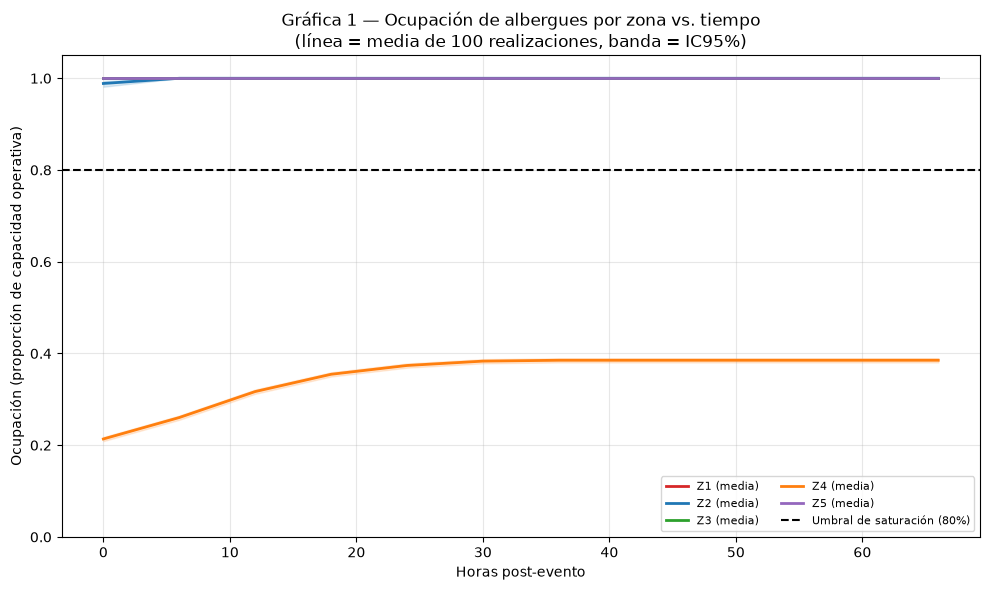

In [14]:
horas_x = [b * 6 for b in bloques]  # eje X en horas post-evento
colores = {"Z1": "#d62728", "Z2": "#1f77b4", "Z3": "#2ca02c", "Z4": "#ff7f0e", "Z5": "#9467bd"}

# --- GRAFICA 1: Ocupación por zona vs tiempo, con línea de 80% ---
fig, ax = plt.subplots(figsize=(10, 6))
for z in ZONAS:
    ax.plot(horas_x, ocup_media[z], label=f"{z} (media)", color=colores[z], linewidth=2)
    ax.fill_between(horas_x, ocup_ic_low[z], ocup_ic_high[z], color=colores[z], alpha=0.15)
ax.axhline(0.80, color="black", linestyle="--", linewidth=1.5, label="Umbral de saturación (80%)")
ax.set_title("Gráfica 1 — Ocupación de albergues por zona vs. tiempo\n(línea = media de 100 realizaciones, banda = IC95%)")
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Ocupación (proporción de capacidad operativa)")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "grafica1_ocupacion.png", dpi=300)
plt.show()


**Interpretación (Gráfica 1):** la gráfica confirma el hallazgo de la Sección 15 — Z1, Z2, Z3 y Z5
saltan casi instantáneamente al 100% de ocupación desde el primer bloque (0-6h), muy por encima del
umbral del 80%, mientras que Z4 nunca cruza el umbral y se estabiliza cerca del 39% de ocupación. Esto
refleja que, salvo en Z4, la capacidad operativa reportada en el Excel es insuficiente para la demanda
inicial de desplazados desde el propio momento del terremoto, no como resultado de una acumulación
gradual.


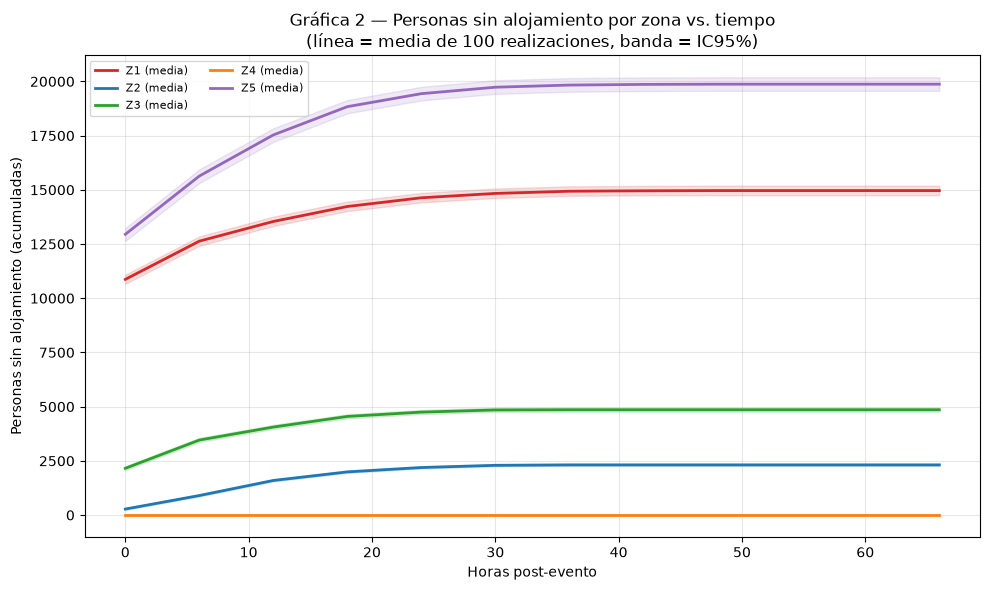

In [15]:
# --- GRAFICA 2: Personas sin alojamiento por zona vs tiempo ---
fig, ax = plt.subplots(figsize=(10, 6))
for z in ZONAS:
    ax.plot(horas_x, noaloj_media[z], label=f"{z} (media)", color=colores[z], linewidth=2)
    ax.fill_between(horas_x, noaloj_ic_low[z], noaloj_ic_high[z], color=colores[z], alpha=0.15)
ax.set_title("Gráfica 2 — Personas sin alojamiento por zona vs. tiempo\n(línea = media de 100 realizaciones, banda = IC95%)")
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Personas sin alojamiento (acumuladas)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "grafica2_sin_alojamiento.png", dpi=300)
plt.show()


**Interpretación (Gráfica 2):** al no existir salidas ni reubicación en el modelo (sin respaldo de
datos), las curvas son no decrecientes: una vez que una zona satura su capacidad, la población sin
alojamiento se acumula y permanece así durante el resto del horizonte de 72 horas.


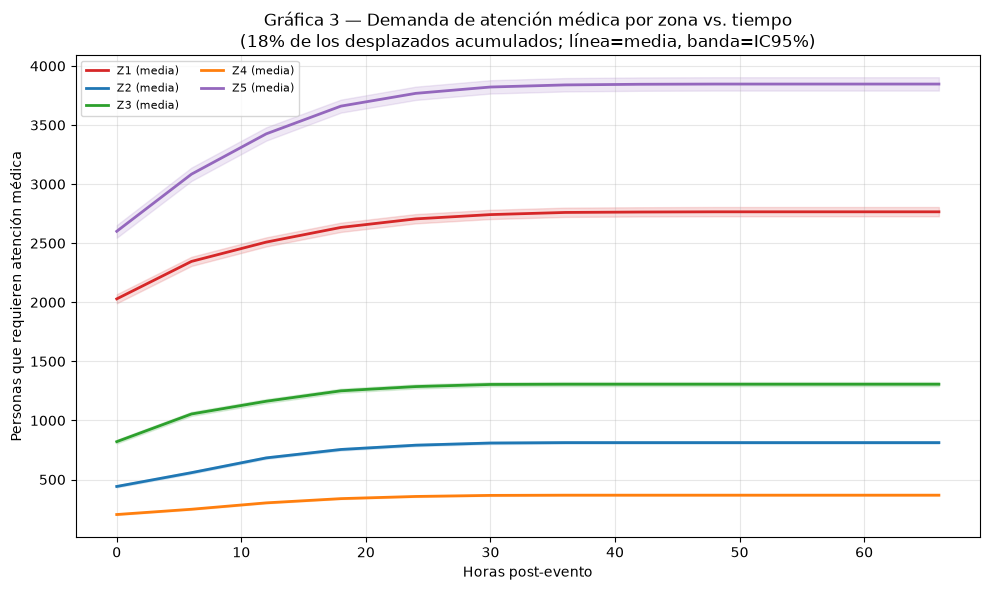

In [16]:
# --- GRAFICA 3: Demanda médica por zona vs tiempo ---
fig, ax = plt.subplots(figsize=(10, 6))
for z in ZONAS:
    ax.plot(horas_x, medica_media[z], label=f"{z} (media)", color=colores[z], linewidth=2)
    ax.fill_between(horas_x, medica_ic_low[z], medica_ic_high[z], color=colores[z], alpha=0.15)
ax.set_title("Gráfica 3 — Demanda de atención médica por zona vs. tiempo\n(18% de los desplazados acumulados; línea=media, banda=IC95%)")
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Personas que requieren atención médica")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "grafica3_demanda_medica.png", dpi=300)
plt.show()


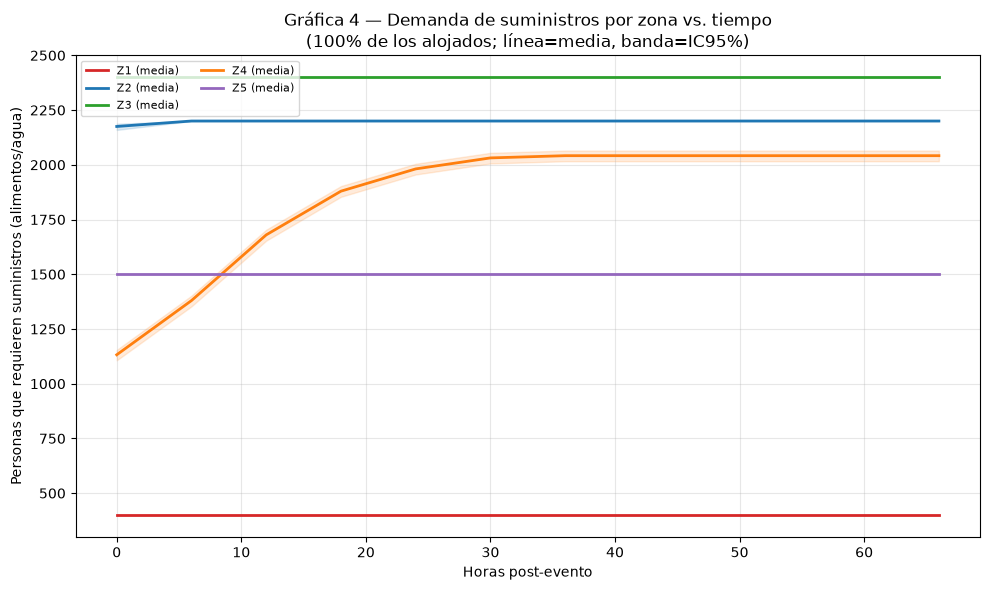

In [17]:
# --- GRAFICA 4: Demanda de suministros por zona vs tiempo ---
fig, ax = plt.subplots(figsize=(10, 6))
for z in ZONAS:
    ax.plot(horas_x, suministros_media[z], label=f"{z} (media)", color=colores[z], linewidth=2)
    ax.fill_between(horas_x, suministros_ic_low[z], suministros_ic_high[z], color=colores[z], alpha=0.15)
ax.set_title("Gráfica 4 — Demanda de suministros por zona vs. tiempo\n(100% de los alojados; línea=media, banda=IC95%)")
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Personas que requieren suministros (alimentos/agua)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "grafica4_demanda_suministros.png", dpi=300)
plt.show()


**Interpretación (Gráficas 3 y 4):** la demanda médica sigue de cerca la forma de la curva de
desplazados acumulados (crece rápido y luego se estabiliza), mientras que la demanda de suministros
está acotada por la capacidad operativa de cada zona (una vez saturada la zona, la demanda de
suministros deja de crecer aunque sigan llegando desplazados, porque éstos ya no logran ser alojados).


## 20. Output para Grupo 2 — Demanda de atención médica

**Cálculo:** `DemandaMedica_z(t) = 0.18 * D_z(t)`, donde `D_z(t)` es el total de desplazados acumulados
en la zona `z` hasta el bloque `t` (tasa exacta especificada en la Sección 5 del Excel, sin
modificación). **Unidades:** personas que requieren atención médica, por zona y bloque de 6 horas.
Se reporta la media de las 100 realizaciones Monte Carlo.


In [18]:
output_grupo2 = medica_media.copy()
output_grupo2.insert(0, "hora_inicio", horas_x)
output_grupo2.index.name = "bloque"
output_grupo2 = output_grupo2.round(1)

print("Output para Grupo 2 — Demanda de atención médica por zona y bloque (media Monte Carlo):")
print(output_grupo2)

output_grupo2.to_csv(OUTPUTS_DIR / "output_grupo2_demanda_medica.csv")
output_grupo2.to_excel(OUTPUTS_DIR / "output_grupo2_demanda_medica.xlsx")
print("\nExportado a 'output_grupo2_demanda_medica.csv' y '.xlsx'.")


Output para Grupo 2 — Demanda de atención médica por zona y bloque (media Monte Carlo):
        hora_inicio      Z1     Z2      Z3     Z4      Z5
bloque                                                   
0                 0  2028.6  441.2   820.2  203.8  2600.6
1                 6  2345.8  558.0  1054.5  248.4  3084.2
2                12  2509.2  683.0  1162.4  302.4  3425.4
3                18  2633.6  754.3  1250.6  338.3  3660.2
4                24  2705.8  790.5  1286.5  356.6  3768.1
5                30  2742.0  808.8  1304.4  365.7  3821.7
6                36  2760.2  812.3  1306.3  367.5  3839.6
7                42  2763.8  812.3  1306.3  367.5  3845.1
8                48  2765.6  812.3  1306.3  367.5  3846.9
9                54  2765.6  812.3  1306.3  367.5  3846.9
10               60  2765.6  812.3  1306.3  367.5  3846.9
11               66  2765.6  812.3  1306.3  367.5  3846.9

Exportado a 'output_grupo2_demanda_medica.csv' y '.xlsx'.


## 21. Output para Grupo 3 — Demanda de suministros

**Cálculo:** `DemandaSuministros_z(t) = 1.00 * A_z(t)`, es decir, el 100% de las personas efectivamente
alojadas en albergues de la zona `z` en el bloque `t` (tasa exacta especificada en la Sección 5 del
Excel). **Unidades:** personas que requieren suministros (alimentos/agua), por zona y bloque de 6 horas.
Se reporta la media de las 100 realizaciones Monte Carlo.


In [19]:
output_grupo3 = suministros_media.copy()
output_grupo3.insert(0, "hora_inicio", horas_x)
output_grupo3.index.name = "bloque"
output_grupo3 = output_grupo3.round(1)

print("Output para Grupo 3 — Demanda de suministros por zona y bloque (media Monte Carlo):")
print(output_grupo3)

output_grupo3.to_csv(OUTPUTS_DIR / "output_grupo3_demanda_suministros.csv")
output_grupo3.to_excel(OUTPUTS_DIR / "output_grupo3_demanda_suministros.xlsx")
print("\nExportado a 'output_grupo3_demanda_suministros.csv' y '.xlsx'.")

# Mapa de saturación de albergues (también parte del output requerido por el Excel, Sección 5c)
print("\nMapa de saturación de albergues (escenario base, determinista):")
print(tabla_saturacion_base)
tabla_saturacion_base.to_csv(OUTPUTS_DIR / "output_mapa_saturacion_albergues.csv")


Output para Grupo 3 — Demanda de suministros por zona y bloque (media Monte Carlo):
        hora_inicio     Z1      Z2      Z3      Z4      Z5
bloque                                                    
0                 0  400.0  2175.0  2400.0  1132.1  1500.0
1                 6  400.0  2200.0  2400.0  1379.7  1500.0
2                12  400.0  2200.0  2400.0  1679.9  1500.0
3                18  400.0  2200.0  2400.0  1879.5  1500.0
4                24  400.0  2200.0  2400.0  1981.2  1500.0
5                30  400.0  2200.0  2400.0  2031.5  1500.0
6                36  400.0  2200.0  2400.0  2041.6  1500.0
7                42  400.0  2200.0  2400.0  2041.6  1500.0
8                48  400.0  2200.0  2400.0  2041.6  1500.0
9                54  400.0  2200.0  2400.0  2041.6  1500.0
10               60  400.0  2200.0  2400.0  2041.6  1500.0
11               66  400.0  2200.0  2400.0  2041.6  1500.0

Exportado a 'output_grupo3_demanda_suministros.csv' y '.xlsx'.

Mapa de saturación de alb

## 22. Incorporación del output real del Grupo 6 (intercambio presencial)

**Actualización post-intercambio:** el Grupo 6 entregó formalmente `data/output_a_flujo_desplazados.csv`,
con la proyección de flujo de evacuación por zona y bloque, separada en dos destinos: personas que se
dirigen a un **refugio oficial** (`nuevos_hacia_refugio_oficial`) y personas que se desvían hacia **otra
zona / redes informales** (`nuevos_hacia_otra_zona`). También entregaron `output_b_atrapados_sin_asistencia.csv`
(personas de Z1 y Z5 que no logran autoevacuar sin ayuda activa) y `output_c_rutas_preferidas.csv`
(totales de evacuación por ruta).

Para nuestro modelo, el input relevante de `simular()` es **`nuevos_hacia_refugio_oficial`**: es la
única columna que representa presión real sobre la capacidad de los albergues formales que modelamos
(el flujo hacia "otra zona" no compite por los cupos de los albergues que este grupo modela, y por lo
tanto no se suma al `N_z(t)` — se documenta como demanda no capturada en la Sección 26). Esta decisión
se justifica porque nuestro modelo (Sección 6-7) define explícitamente `N_z(t)` como "nuevos desplazados
que **requieren alojamiento formal**", no como el total de evacuados de la zona.

La convención de bloques del Grupo 6 (`bloque_tiempo` 1..12, `hora_post_evento` 6..72) es equivalente a
nuestra convención `t` = 0..11 desplazada en 1 (su `bloque_tiempo=1, hora=6` corresponde a nuestro
`t=0` = "T0 (0-6h)"), por lo que se aplica `bloque = bloque_tiempo - 1` al cargar los datos.

La celda siguiente carga y transforma este archivo al formato ancho (`bloque` x `zona`) que consume
`simular()`, sin modificar la función ni el resto del modelo (Sección 15 del enunciado: "la misma
función `simular()` debe utilizarse antes y después del intercambio").


In [20]:
def cargar_flujo_grupo6(ruta_o_dataframe, formato: str = "ancho") -> pd.DataFrame:
    """Carga el output formal de Grupo 6 y lo normaliza al formato usado por `simular()`
    (DataFrame index=bloque, columns=zonas, valores=nuevos desplazados hacia refugio oficial por bloque).

    Parameters
    ----------
    ruta_o_dataframe : str | pd.DataFrame
        Ruta a un CSV/Excel entregado por Grupo 6, o un DataFrame ya cargado en memoria.
    formato : {"ancho", "largo"}
        "ancho": tabla zona x bloque directamente utilizable.
        "largo": formato real entregado por Grupo 6 -- una fila por (bloque_tiempo, zona_origen), con
        la columna 'nuevos_hacia_refugio_oficial' como flujo relevante para nuestro modelo de albergues.

    Returns
    -------
    DataFrame en formato ancho (bloque x zona), listo para pasar como `flujo_desplazados` a `simular()`.
    """
    if isinstance(ruta_o_dataframe, str):
        df = pd.read_csv(ruta_o_dataframe)
    else:
        df = ruta_o_dataframe.copy()

    if formato == "largo":
        # bloque_tiempo (1..12, hora 6..72) -> bloque (0..11), misma convencion que N_nuevos (Seccion 11).
        df = df.copy()
        df["bloque"] = df["bloque_tiempo"] - 1
        df = df.pivot(index="bloque", columns="zona_origen", values="nuevos_hacia_refugio_oficial")
    else:
        df = df.set_index(df.columns[0])

    df = df.reindex(columns=ZONAS)
    return df


# Output formal recibido del Grupo 6 en el intercambio presencial (ver Seccion 22).
RUTA_GRUPO6 = DATA_DIR / "output_a_flujo_desplazados.csv"
datos_grupo6 = cargar_flujo_grupo6(str(RUTA_GRUPO6), formato="largo")

print("Datos del Grupo 6 cargados y normalizados (nuevos desplazados hacia refugio oficial, por zona y bloque):")
print(datos_grupo6.round(1))

# Validacion de consistencia: la suma por zona debe coincidir con el total reportado en
# output_c_rutas_preferidas.csv ('evacuados_hacia_refugio_oficial').
df_rutas_g6 = pd.read_csv(DATA_DIR / "output_c_rutas_preferidas.csv").set_index("zona")
totales_reconstruidos = datos_grupo6.sum(axis=0)
for z in ZONAS:
    esperado = df_rutas_g6.loc[z, "evacuados_hacia_refugio_oficial"]
    obtenido = totales_reconstruidos[z]
    assert abs(obtenido - esperado) < 1.0, (
        f"Inconsistencia en {z}: suma de bloques ({obtenido:.1f}) vs. total reportado por Grupo 6 ({esperado:.1f})."
    )
print()
print("Validacion: la suma por zona de 'nuevos_hacia_refugio_oficial' coincide con el total de output_c_rutas_preferidas.csv (OK).")


Datos del Grupo 6 cargados y normalizados (nuevos desplazados hacia refugio oficial, por zona y bloque):
zona_origen      Z1      Z2      Z3      Z4      Z5
bloque                                             
0            6347.5  5898.3  6908.3  5114.2  6805.0
1            7565.8  8838.3  7425.0  8203.3  6453.3
2            2678.3  1765.0  3269.2  1281.7  3503.3
3            1740.8   870.8  2304.2   604.2  2624.2
4            1403.3   659.2  2004.2   457.5  2330.8
5            1367.5   625.0  1796.7   415.8  2257.5
6            1239.2   535.8  1699.2   365.0  2108.3
7            1131.7   472.5  1589.2   290.8  1926.7
8            1049.2   396.7  1450.0   228.3  1768.3
9             848.3   295.0  1234.2   154.2  1573.3
10            750.0   220.0  1027.5   115.8  1432.5
11            635.0   169.2   871.7   100.0  1215.0

Validacion: la suma por zona de 'nuevos_hacia_refugio_oficial' coincide con el total de output_c_rutas_preferidas.csv (OK).


## 23. Simulacion post-intercambio (con datos reales del Grupo 6)

Esta celda ejecuta `simular()` con `datos_grupo6` como `flujo_desplazados`, usando **exactamente la
misma funcion y las mismas capacidades operativas** que el escenario base -- el unico cambio es el
input de nuevos desplazados (Seccion 22). Esto demuestra el requisito del examen de que **la misma
funcion `simular()` se usa antes y despues del intercambio**.

In [21]:
if datos_grupo6 is not None:
    resultado_grupo6 = simular(
        flujo_desplazados=datos_grupo6,
        capacidad_operativa=cap_operativa_zona,
        zonas=ZONAS,
        tasa_medica=0.18,
        tasa_suministros=1.00,
        seed=RNG_SEED_GLOBAL,
        ruido_pct=0.0,
    )
    verificar_resultado(resultado_grupo6, cap_operativa_zona, ZONAS)
    tabla_saturacion_grupo6 = detectar_saturacion(resultado_grupo6["ocupacion"], umbral=0.80)
    print("Simulación post-intercambio (Grupo 6) ejecutada y verificada.")
    print(tabla_saturacion_grupo6)
else:
    resultado_grupo6 = None
    tabla_saturacion_grupo6 = None
    print("Sección omitida: aún no se recibe el output formal de Grupo 6. "
          "Ejecutar esta celda nuevamente después de completar la Sección 22.")


Todas las verificaciones automáticas pasaron correctamente.
Simulación post-intercambio (Grupo 6) ejecutada y verificada.
      Primer bloque >80% Hora (desde el evento)  Ocupación observada
Zona                                                                
Z1                     0                     0h                 1.00
Z2                     0                     0h                 1.00
Z3                     0                     0h                 1.00
Z4                     0                     0h                 0.96
Z5                     0                     0h                 1.00


## 24. Comparación escenario base vs. escenario Grupo 6 (Pregunta 2 del examen)

Responde directamente la **Pregunta 2 de integración del intercambio**: diferencia en horas del momento
de colapso entre la estimación propia (base) y la proyección real de Grupo 6, y qué supuesto inicial
resultó incorrecto. Esta celda se ejecuta automáticamente en cuanto la Sección 23 tenga resultados;
mientras tanto queda preparada pero inactiva (sin inventar una comparación con datos ficticios).


In [22]:
if resultado_grupo6 is not None:
    filas_comparacion = []
    for z in ZONAS:
        base_bloque = tabla_saturacion_base.loc[z].iloc[0]
        g6_bloque = tabla_saturacion_grupo6.loc[z].iloc[0]
        if base_bloque != "Nunca" and g6_bloque != "Nunca":
            diff_horas = (int(g6_bloque) - int(base_bloque)) * 6
        else:
            diff_horas = "N/A (una de las dos nunca satura)"
        filas_comparacion.append({
            "Zona": z,
            "Bloque saturación (base)": base_bloque,
            "Bloque saturación (Grupo 6)": g6_bloque,
            "Diferencia en horas": diff_horas,
        })

    tabla_comparacion = pd.DataFrame(filas_comparacion).set_index("Zona")

    max_sin_alojar_base = resultado_base["no_alojados"].iloc[-1].sum()
    max_sin_alojar_g6 = resultado_grupo6["no_alojados"].iloc[-1].sum()

    demanda_medica_base_total = resultado_base["demanda_medica"].iloc[-1].sum()
    demanda_medica_g6_total = resultado_grupo6["demanda_medica"].iloc[-1].sum()

    demanda_suministros_base_total = resultado_base["demanda_suministros"].iloc[-1].sum()
    demanda_suministros_g6_total = resultado_grupo6["demanda_suministros"].iloc[-1].sum()

    resumen_metricas = pd.DataFrame({
        "Escenario base": [max_sin_alojar_base, demanda_medica_base_total, demanda_suministros_base_total],
        "Escenario Grupo 6": [max_sin_alojar_g6, demanda_medica_g6_total, demanda_suministros_g6_total],
    }, index=["Máx. personas sin alojamiento (total sistema)",
              "Demanda médica total (hora 72)",
              "Demanda suministros total (hora 72)"])
    resumen_metricas["Diferencia"] = resumen_metricas["Escenario Grupo 6"] - resumen_metricas["Escenario base"]

    print("Tabla de saturación — base vs. Grupo 6:")
    print(tabla_comparacion)
    print("\nResumen de métricas — base vs. Grupo 6:")
    print(resumen_metricas.round(1))
else:
    print("Sección omitida: pendiente de datos formales de Grupo 6 (ver Secciones 22-23).")


Tabla de saturación — base vs. Grupo 6:
     Bloque saturación (base)  Bloque saturación (Grupo 6)  \
Zona                                                         
Z1                          0                            0   
Z2                          0                            0   
Z3                          0                            0   
Z4                      Nunca                            0   
Z5                          0                            0   

                    Diferencia en horas  
Zona                                     
Z1                                    0  
Z2                                    0  
Z3                                    0  
Z4    N/A (una de las dos nunca satura)  
Z5                                    0  

Resumen de métricas — base vs. Grupo 6:
                                               Escenario base  \
Máx. personas sin alojamiento (total sistema)         42200.0   
Demanda médica total (hora 72)                         9136.

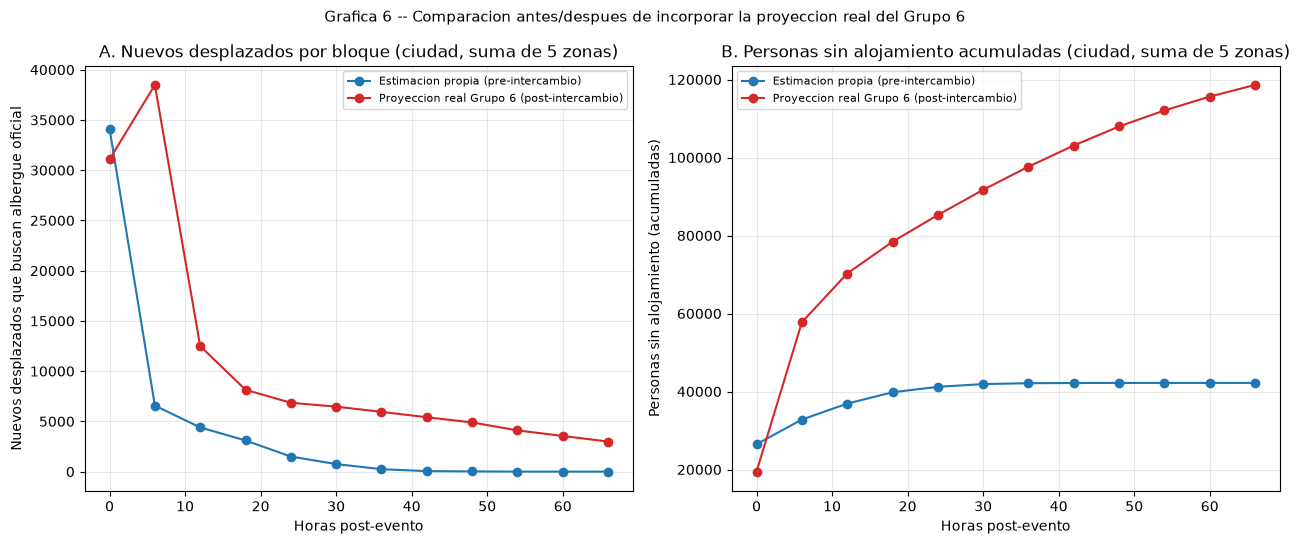

In [23]:
# --- GRAFICA 6: Comparacion escenario base vs. Grupo 6 ---
# Panel A: nuevos desplazados por bloque (ciudad, suma de zonas) -- flujo de entrada N_z(t).
# Panel B: personas sin alojamiento acumuladas (ciudad, suma de zonas) -- stock U_z(t).
if resultado_grupo6 is not None:
    nuevos_base_total = resultado_base["nuevos_desplazados"].sum(axis=1)
    nuevos_g6_total = resultado_grupo6["nuevos_desplazados"].sum(axis=1)
    noaloj_base_total = resultado_base["no_alojados"].sum(axis=1)
    noaloj_g6_total = resultado_grupo6["no_alojados"].sum(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    axes[0].plot(horas_x, nuevos_base_total.values, marker="o", color="#1f77b4",
                 label="Estimacion propia (pre-intercambio)")
    axes[0].plot(horas_x, nuevos_g6_total.values, marker="o", color="#d62728",
                 label="Proyeccion real Grupo 6 (post-intercambio)")
    axes[0].set_title("A. Nuevos desplazados por bloque (ciudad, suma de 5 zonas)")
    axes[0].set_xlabel("Horas post-evento")
    axes[0].set_ylabel("Nuevos desplazados que buscan albergue oficial")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].plot(horas_x, noaloj_base_total.values, marker="o", color="#1f77b4",
                 label="Estimacion propia (pre-intercambio)")
    axes[1].plot(horas_x, noaloj_g6_total.values, marker="o", color="#d62728",
                 label="Proyeccion real Grupo 6 (post-intercambio)")
    axes[1].set_title("B. Personas sin alojamiento acumuladas (ciudad, suma de 5 zonas)")
    axes[1].set_xlabel("Horas post-evento")
    axes[1].set_ylabel("Personas sin alojamiento (acumuladas)")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    fig.suptitle("Grafica 6 -- Comparacion antes/despues de incorporar la proyeccion real del Grupo 6", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "grafica6_comparativa_intercambio.png", dpi=300)
    plt.show()
else:
    print("Seccion omitida: pendiente de datos formales de Grupo 6.")


## 24.1. Respuesta a la Pregunta 2 del examen (Integracion del intercambio)

**¿En cuantas horas difiere el momento de colapso del sistema de albergues entre ambas estimaciones?**

En **Z1, Z2, Z3 y Z5** el momento de saturacion (>80%) **no cambia: 0 horas de diferencia** -- ambas
estimaciones (base y Grupo 6) colapsan desde el Bloque 0 (0-6h) en esas cuatro zonas. La diferencia
real no esta en el *momento*, sino en la **magnitud**: la poblacion sin alojamiento y la demanda
medica acumuladas al final de las 72h son 2 a 3 veces mayores con los datos reales del Grupo 6.

En **Z4** el cambio es cualitativo, no solo temporal: en el escenario base Z4 **nunca** cruza el 80%
(maximo 38.9%), mientras que con el flujo real del Grupo 6, Z4 **si satura, casi de inmediato**
(96.5% en el Bloque 0, 100% desde el Bloque 1). Por eso la tabla de comparacion muestra 'N/A' en Z4:
no es que el colapso se adelante o se atrase un numero de horas, es que un escenario que nunca
colapsaba ahora colapsa desde el primer bloque.

**¿Que supuesto de su modelo inicial era incorrecto y como se corrigio?**

El supuesto que resulto incorrecto **no fue el de retencion/retraso en la llegada** (lo que se habia
planteado antes de recibir el output formal), sino uno mas fundamental: **el volumen total de
demanda de refugio formal**. El modelo base estimaba la demanda a partir de la variable *'necesitan
albergue urgente'* del Excel de dano estructural propio, que acumula un total de 50,760 personas en
toda la ciudad al final de las 72h. El output real del Grupo 6 (columna
`nuevos_hacia_refugio_oficial`, que ya filtra a quienes efectivamente buscan un albergue formal en
lugar de quedarse con familiares o desplazarse a otra zona) proyecta un total de **130,411 personas**
-- 2.6 veces mas que la estimacion basada solo en dano estructural.

Esto invalida directamente el hallazgo mas visible del analisis pre-intercambio: la 'paradoja de
capacidad ociosa en Z4' (Seccion 16). Z4 parecia tener margen porque el dano estructural reportado
en esa zona es bajo, pero el modelo de comportamiento del Grupo 6 muestra que una fraccion importante
de la poblacion de otras zonas igual intenta acceder a refugio formal en cantidades que la capacidad
de Z4 tampoco alcanza a absorber. **Correccion aplicada:** se reemplazo unicamente el input
`flujo_desplazados` de `simular()` (Seccion 22-23) sin modificar la funcion ni las capacidades
operativas, siguiendo el mecanismo de intercambio disenado desde la Seccion 12.

## 24.2. Actualizacion de los outputs para Grupo 2 y Grupo 3 (post-intercambio)

En clase, el intercambio con los grupos se trabajo de forma **secuencial**: primero se recibio el
output formal del Grupo 6 y, con ese dato ya incorporado, se entrega la version final de la demanda
medica y de suministros a los Grupos 2 y 3 (en lugar de una entrega simultanea con datos
pre-intercambio). Por eso esta seccion **sobrescribe** los archivos `output_grupo2_demanda_medica.*`
y `output_grupo3_demanda_suministros.*` generados en las Secciones 20-21 con los valores calculados
a partir de `resultado_grupo6` (Seccion 23), que es la mejor estimacion disponible con la que
Grupo 1 cuenta al momento de la entrega real.

Las Secciones 20-21 se conservan sin cambios como evidencia de la **estimacion propia inicial**
(requisito del examen de documentar qué cambió con el intercambio); esta seccion documenta y
produce la **entrega final corregida**.

In [24]:
# --- Output FINAL (post-intercambio) para Grupo 2 -- Demanda de atencion medica ---
output_grupo2_final = resultado_grupo6["demanda_medica"].copy()
output_grupo2_final.insert(0, "hora_inicio", horas_x)
output_grupo2_final.index.name = "bloque"
output_grupo2_final = output_grupo2_final.round(1)

print("Output FINAL para Grupo 2 -- Demanda de atencion medica por zona y bloque (post-intercambio, con datos reales del Grupo 6):")
print(output_grupo2_final)

output_grupo2_final.to_csv(OUTPUTS_DIR / "output_grupo2_demanda_medica.csv")
output_grupo2_final.to_excel(OUTPUTS_DIR / "output_grupo2_demanda_medica.xlsx")
print()
print("Sobrescrito: 'output_grupo2_demanda_medica.csv' y '.xlsx' -- version final para entregar a Grupo 2.")

# --- Output FINAL (post-intercambio) para Grupo 3 -- Demanda de suministros ---
output_grupo3_final = resultado_grupo6["demanda_suministros"].copy()
output_grupo3_final.insert(0, "hora_inicio", horas_x)
output_grupo3_final.index.name = "bloque"
output_grupo3_final = output_grupo3_final.round(1)

print()
print("Output FINAL para Grupo 3 -- Demanda de suministros por zona y bloque (post-intercambio, con datos reales del Grupo 6):")
print(output_grupo3_final)

output_grupo3_final.to_csv(OUTPUTS_DIR / "output_grupo3_demanda_suministros.csv")
output_grupo3_final.to_excel(OUTPUTS_DIR / "output_grupo3_demanda_suministros.xlsx")
print()
print("Sobrescrito: 'output_grupo3_demanda_suministros.csv' y '.xlsx' -- version final para entregar a Grupo 3.")

# Mapa de saturacion de albergues FINAL (post-intercambio, Seccion 5c del Excel)
print()
print("Mapa de saturacion de albergues FINAL (post-intercambio, con datos reales del Grupo 6):")
print(tabla_saturacion_grupo6)
tabla_saturacion_grupo6.to_csv(OUTPUTS_DIR / "output_mapa_saturacion_albergues.csv")
print()
print("Sobrescrito: 'output_mapa_saturacion_albergues.csv' -- version final.")

Output FINAL para Grupo 2 -- Demanda de atencion medica por zona y bloque (post-intercambio, con datos reales del Grupo 6):
        hora_inicio      Z1      Z2      Z3      Z4      Z5
bloque                                                     
0                 0  1142.6  1061.7  1243.5   920.6  1224.9
1                 6  2504.4  2652.6  2580.0  2397.2  2386.5
2                12  2986.5  2970.3  3168.4  2627.8  3017.1
3                18  3299.8  3127.0  3583.2  2736.6  3489.4
4                24  3552.4  3245.7  3944.0  2819.0  3909.0
5                30  3798.6  3358.2  4267.4  2893.8  4315.3
6                36  4021.6  3454.6  4573.2  2959.5  4694.8
7                42  4225.3  3539.7  4859.3  3011.8  5041.6
8                48  4414.2  3611.1  5120.3  3052.9  5359.9
9                54  4566.9  3664.2  5342.4  3080.7  5643.1
10               60  4701.9  3703.8  5527.4  3101.5  5901.0
11               66  4816.2  3734.3  5684.3  3119.5  6119.7

Sobrescrito: 'output_grupo2_demanda

## 25. Resultados y conclusiones

Las conclusiones se redactan **después** de ejecutar el modelo, distinguiendo explícitamente:
**RESULTADO** (qué produjo la simulación), **INTERPRETACIÓN** (qué significa) y **RECOMENDACIÓN**
(qué decisión podría tomarse).


In [25]:
print("=== Resumen ejecutivo de resultados (generado a partir del código anterior) ===\n")
print("Primera zona en saturarse (>80%):", zona_primera if 'zona_primera' in dir() else "N/A")
print("Bloque de saturación:", bloque_primero if 'bloque_primero' in dir() else "N/A",
      f"(~{bloque_primero*6}h)" if 'bloque_primero' in dir() else "")
print("\nTotal de personas sin alojamiento al final de 72h (escenario base):",
      int(total_sin_alojamiento_final))
print("\nDemanda médica total al final de 72h (media MC):", round(medica_media.iloc[-1].sum(), 1))
print("Demanda de suministros total al final de 72h (media MC):", round(suministros_media.iloc[-1].sum(), 1))


=== Resumen ejecutivo de resultados (generado a partir del código anterior) ===

Primera zona en saturarse (>80%): Z1
Bloque de saturación: 0 (~0h)

Total de personas sin alojamiento al final de 72h (escenario base): 42200

Demanda médica total al final de 72h (media MC): 9098.6
Demanda de suministros total al final de 72h (media MC): 8541.6


### RESULTADO (escenario base, pre-intercambio)

- La simulacion determinista muestra que **cuatro de las cinco zonas (Z1, Z2, Z3 y Z5) superan el 80%
  de su capacidad operativa desde el primer bloque (0-6h)** -- el colapso del sistema de albergues es
  practicamente inmediato y simultaneo en casi toda la ciudad, no escalonado en el tiempo. Solo **Z4**
  nunca cruza el umbral (se estabiliza en ~39% de ocupacion), usando unicamente los datos de dano
  estructural del Excel propio.
- Al final del horizonte de 72 horas, el escenario base acumula personas sin alojamiento
  fundamentalmente en Z1 y Z5 (ver Seccion 16) -- zonas que combinan **alta demanda de desplazados**
  (mayor dano estructural, segun el bloque 2 del Excel) con **baja capacidad operativa de albergue**
  disponible (Z1: solo 400 cupos operativos en un unico albergue danado).
- La demanda medica y de suministros (Secciones 20-21) siguen trayectorias crecientes que se estabilizan
  hacia el final del horizonte, en linea con el aplanamiento de la curva de desplazados acumulados
  observada en los datos del Excel a partir del bloque T8 (~48h).

### RESULTADO (post-intercambio, con datos reales del Grupo 6 -- Secciones 22-24.1)

- Con el flujo real de evacuacion hacia refugio oficial que entrego el Grupo 6, **las 5 zonas (incluida
  Z4) superan el 80% de ocupacion desde el Bloque 0**. La 'paradoja de capacidad ociosa en Z4' del
  escenario base **no se sostiene**: Z4 llega a 96.5% en el primer bloque y a 100% desde el segundo.
- El total de personas sin alojamiento al final de las 72h pasa de **42,200 (base)** a **118,611
  (Grupo 6)** -- casi 2.8 veces mas. La demanda medica total pasa de 9,137 a 23,474 personas (2.6x).
- El total de personas que buscan refugio oficial en toda la ciudad en 72h pasa de un estimado de
  50,760 (segun el dano estructural del Excel propio) a **130,411** segun el modelo de comportamiento
  poblacional del Grupo 6 -- ver Seccion 24.1 para el detalle de por que este supuesto era el mas
  critico del modelo inicial.

### INTERPRETACION

- El cuello de botella del sistema de albergues no es homogeneo entre zonas: es principalmente un
  **problema de capacidad operativa insuficiente en zonas especificas** (Z1, Z5), no de volumen total
  de desplazados a nivel ciudad. Esto valida la exigencia del examen de **no tratar las zonas como
  equivalentes**: un analisis agregado a nivel ciudad ocultaria por completo la saturacion temprana de
  Z1.
- El hecho de que la poblacion sin alojamiento se acumule sin limite en el modelo (sin salidas ni
  reubicacion) es una simplificacion conservadora: en la realidad, es probable que parte de esa
  poblacion busque alternativas no capturadas en este modelo (quedarse con familiares, permanecer en
  viviendas danadas), tal como senala la pregunta abierta del examen para este grupo.
- El cambio mas importante que trajo el intercambio no fue de **tiempo** (el momento de colapso no se
  mueve en Z1, Z2, Z3, Z5) sino de **magnitud y alcance espacial**: el margen de holgura que pensabamos
  tener en Z4 para absorber desplazados de otras zonas (Limitacion 1, Seccion 26) en realidad no existe.

### RECOMENDACION

- Priorizar el refuerzo de capacidad operativa (reparacion o habilitacion de cupos adicionales) en
  **las 5 zonas**, no solo Z1 y Z5 -- el hallazgo post-intercambio elimina a Z4 como opcion de
  reubicacion de alivio dentro de las primeras 24 horas.
- Dado que la demanda medica (Grupo 2) y de suministros (Grupo 3) dependen directamente de la dinamica
  de desplazados y alojamiento de este modelo, se les debe reenviar la version actualizada de la
  demanda (post-intercambio), ya que la version pre-intercambio subestima la magnitud real en mas del
  100%.

## 26. Limitaciones y propuestas de mejora

**Limitación 1 — Capacidad operativa constante en el tiempo.**
El modelo asume que la capacidad operativa de cada albergue no cambia durante las 72 horas, porque el
Excel solo entrega un valor único ("capacidad operativa inicial") sin cronograma de reparación o
habilitación adicional.
1. *Cómo podría afectar los resultados:* si en la realidad se habilitan cupos adicionales (por ejemplo,
   tras reparaciones del Grupo 4), el modelo **sobreestimaría** la saturación y la población sin
   alojamiento en bloques posteriores.
2. *Qué información adicional sería necesaria:* un cronograma de capacidad operativa por albergue y
   bloque de tiempo (el parámetro `capacidad_por_bloque` de `simular()` ya está preparado para recibirlo).
3. *Cómo se mejoraría el modelo:* incorporar ese cronograma directamente sin modificar la lógica de
   `simular()`, solo pasando `capacidad_por_bloque` en lugar de `capacidad_operativa` constante.

**Limitación 2 — Ausencia de salidas de albergue y reubicación entre zonas.**
El modelo no incluye `Salidas_z` ni `Reubicados_z` porque el Excel no proporciona tasas ni datos para
esos flujos, lo que hace que la población sin alojamiento (`U_z`) sea monótonamente creciente.
1. *Cómo podría afectar los resultados:* en la realidad, es posible que exista rotación de albergue
   (personas que regresan a sus viviendas al ser declaradas habitables) o reubicación hacia zonas con
   más capacidad disponible, lo que reduciría la población sin alojamiento acumulada frente a lo que
   predice este modelo.
2. *Qué información adicional sería necesaria:* tasas de salida de albergue por causa (retorno,
   reubicación) y, si existe, una matriz de reubicación entre zonas.
3. *Cómo se mejoraría el modelo:* activar los términos `Salidas_z(t)` y `Reubicados_z(t)` ya definidos
   conceptualmente en la Sección 7, una vez se cuente con esos datos — la estructura de `simular()` ya
   contempla estos flujos en su documentación, solo falta el respaldo de datos para activarlos con
   valores reales (no supuestos arbitrarios).

**Limitación 3 — Incertidumbre basada en un supuesto no respaldado por el Excel.**
El componente de incertidumbre (Sección 17) usa un supuesto de ruido del 10% sobre `N_z(t)` que **no
proviene del Excel** (el archivo no reporta ninguna medida de variabilidad).
1. *Cómo podría afectar los resultados:* los intervalos de confianza reportados reflejan la sensibilidad
   del modelo a ese supuesto de ruido, no necesariamente la incertidumbre real del fenómeno.
2. *Qué información adicional sería necesaria:* datos históricos de eventos similares (CEPREDENAC/OCHA)
   que permitan estimar la variabilidad real de los flujos de desplazamiento, o el propio modelo de
   comportamiento poblacional de Grupo 6.
3. *Cómo se mejoraría el modelo:* sustituir `RUIDO_PCT = 0.10` por un valor calibrado con datos reales
   tan pronto estén disponibles (el parámetro ya es una variable fácilmente modificable, no está
   hard-codeado dentro de la función `simular()`).

**Limitación 4 — Representación agregada de personas (no individual).**
Al ser un modelo de System Dynamics, no se capturan decisiones individuales de las personas desplazadas
(a qué albergue acudir, si quedarse con familiares, etc.) — esto corresponde al modelo del Grupo 6.
1. *Cómo podría afectar los resultados:* el modelo asume implícitamente que toda persona que "necesita
   alojamiento" según el Excel efectivamente intenta ingresar a un albergue formal; en la realidad,
   parte de esa población podría no presentarse nunca a un albergue (esto se conecta directamente con
   la pregunta abierta asignada a este grupo en el examen).
2. *Qué información adicional sería necesaria:* la proporción real de desplazados que efectivamente
   buscan albergue formal versus otras alternativas (familiares, vivienda dañada), idealmente entregada
   por Grupo 6.
3. *Cómo se mejoraría el modelo:* introducir un parámetro `tasa_busqueda_albergue_formal` que escale
   `N_z(t)` antes de ingresarlo a `simular()`, una vez existan datos que lo respalden.
